## Финальный проект

#### *«Я чувствую себя как функция арктангенса, которая приближается к асимптоте.» — Теория большого взрыва*

Это финальный проект продуктового блока курса «Продуктовые метрики». За него можно получить максимум 60 баллов. На решение отводится **21 календарный день** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена. Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например final_project). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/final_project_data.zip)

In [41]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests

from statsmodels.tsa.seasonal import STL
from scipy.stats import norm
from scipy.stats import t
import math

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

### Case Study. Улучшение сервиса доставки из ресторанов 🌮

**Легенда**   
Вы присоединились к продуктовой команде сервиса доставки из ресторанов в роли аналитика. Близится планирование следующего квартала, пора готовить бэклог инициатив. Продакт-менеджер особенно беспокоится об удовлетворенности пользователей — за последний месяц выросло число отмен и жалоб на задержки.

Вам поставлена задача: провести исследование текущих значений метрик, выдвинуть гипотезу о проблеме и предложить её решение.

In [43]:
df = pd.read_csv(r'C:\Users\lebed\Desktop\ДЗ\data\final_project_delivery.csv')

df.head()

,order_id,order_time,delivery_time,status,cancellation_reason,order_value,delivery_fee,estimated_delivery_time_min,time_to_assign_courier_min,actual_preparation_time_min,travel_time_min,delivery_distance_km,promotion_used,platform,city_region,user_id,user_segment
0,257,2022-11-01 00:01:46,2022-11-01 00:21:52,delivered,NaN,25.73,2.09,27.0,10.2,15.1,5.0,3.48,no,Android,Belem,5737,returning
1,165,2022-11-01 00:06:07,2022-11-01 00:27:01,delivered,NaN,22.00,0.77,13.0,9.0,15.9,5.0,1.29,no,iOS,Parque das Nacoes,4095,new
2,343,2022-11-01 21:07:01,2022-11-01 21:40:07,delivered,NaN,29.90,3.53,44.0,10.6,15.4,15.1,5.88,no,iOS,Parque das Nacoes,15991,returning
3,904,2022-11-01 00:06:48,2022-11-01 00:36:42,delivered,NaN,40.49,2.02,27.0,3.7,16.0,13.9,3.36,no,Android,Alfama,1773,returning
4,555,2022-11-01 00:09:58,2022-11-01 00:57:22,delivered,NaN,35.75,3.48,39.0,5.2,12.3,35.1,5.80,no,iOS,Baixa,5203,returning


Описание данных:

- order_id — уникальный идентификатор заказа
- order_time — timestamp создания заказа
- delivery_time – timestamp доставки заказа
- status — статус заказа, принимает 2 значения: delivered и cancelled
- cancellation_reason — причина отмены заказа: Cancelled by user (отменена пользователем) и No courier available (нет доступных курьеров)
- order_value — стоиомость заказа
- delivery_fee — стоиость доставки
- estimated_delivery_time_min — прогнозное время доставки
- time_to_assign_courier_min — время до назначения курьера
- actual_preparation_time_min — время приготовления заказа рестораном
- travel_time_min — суммарное время на дорогу курьера до ресторана и до конечного пользователя
- delivery_distance_km — расстояние от адреса доставки до адреса ресторана
- promotion_used — был ли заказ совершер с использованием промокода или акции
- platform — платформа, с которой совершен заказ
- city_region — район города, в который планируется доставка
- user_id — уникальный идентификатор пользователя, сделавшего заказ
- user_segment — сегмент пользователя (новый или вернувшийся)    

### Часть 1. Исследование

#### 1. Динамика основных метрик — 3 балла
Рассчитайте и визуализируйте по дням:
- Число заказов, число доставленных заказов (статус delivered);
- Completion Rate (Доставленные заказы / Все заказы), Cancellation Rate (Отмененные заказы / Все заказы);
- Среднее и медианное время доставки в минутах (рассчитывается как разница между delivery_time и order_time), средний чек заказа, среднюю стоимость доставки.

Сделайте выводы:
- Есть ли выраженный тренд?
- Может быть какие-то дни кажутся подозрительными на предмет аномалий?

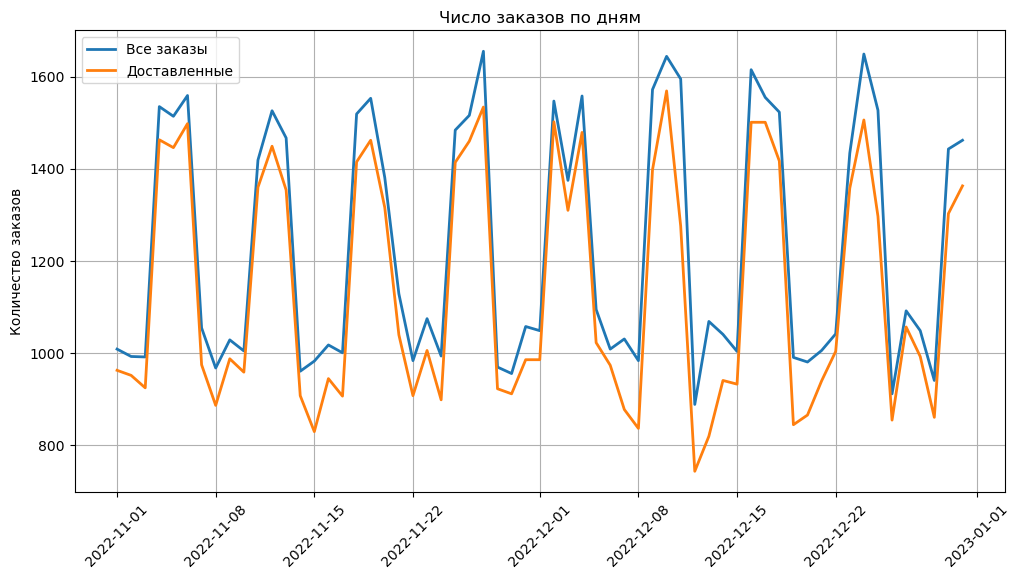

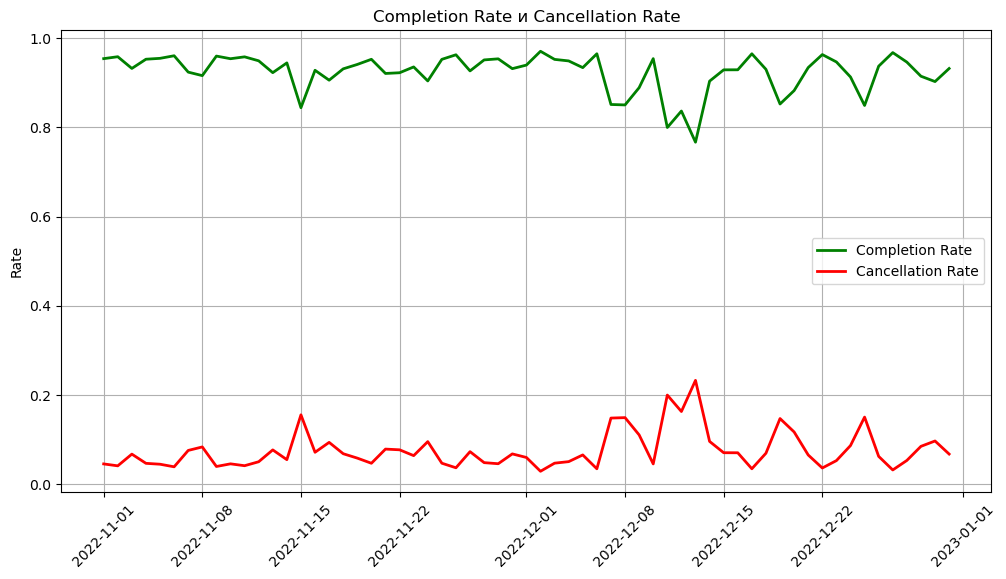

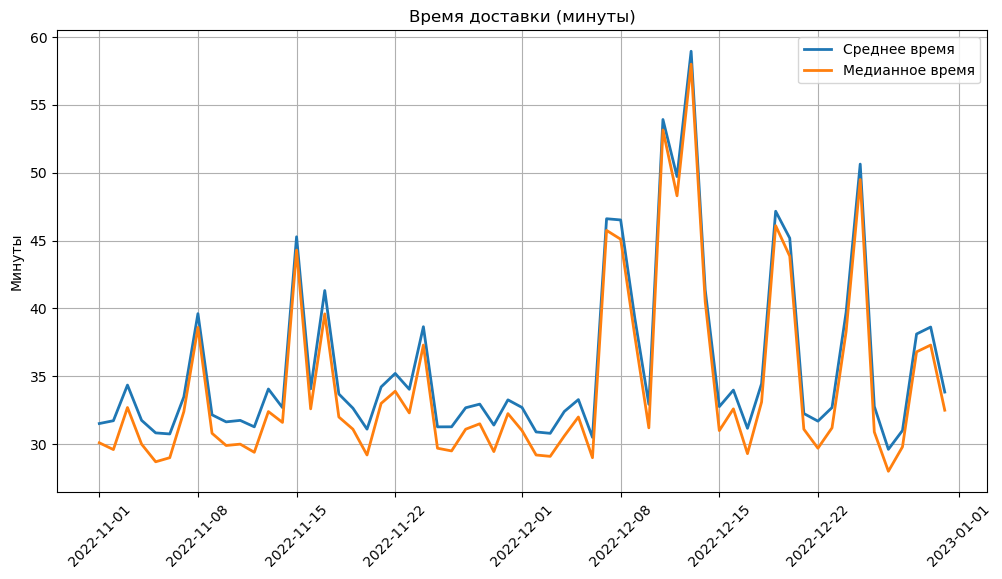

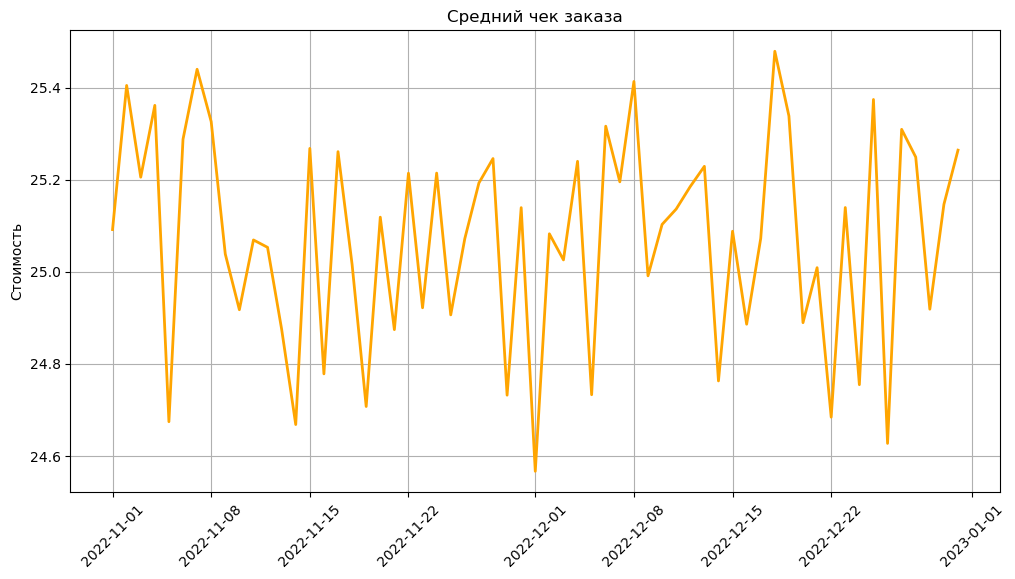

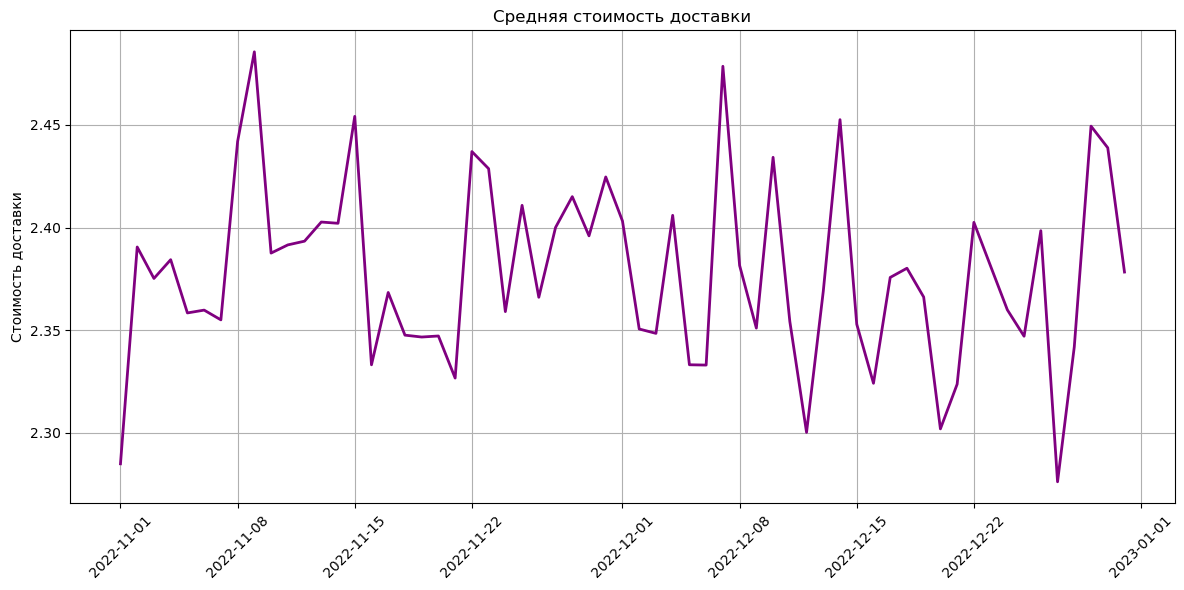

In [45]:
df['order_time'] = pd.to_datetime(df['order_time'])
df['delivery_time'] = pd.to_datetime(df['delivery_time'])

df_orders = df.copy()
df_orders['date'] = [d.date() for d in df_orders['order_time']]

df_orders_all = df_orders.copy().groupby('date')['order_id'].nunique().reset_index()
df_orders_delivered = df_orders[df_orders['status'] == 'delivered'].copy().groupby('date')['order_id'].nunique().reset_index()

df_orders_compl = df_orders_all.merge(df_orders_delivered, on = 'date')
df_orders_compl.columns = ['date', 'all', 'delivered']
df_orders_compl['compl_rate'] = df_orders_compl['delivered'] / df_orders_compl['all']

df_orders_cancelled = df_orders[df_orders['status'] == 'cancelled'].copy().groupby('date')['order_id'].nunique().reset_index()
df_orders_canc = df_orders_all.merge(df_orders_cancelled, on = 'date')
df_orders_canc.columns = ['date', 'all', 'cancelled']
df_orders_canc['canc_rate'] = df_orders_canc['cancelled'] / df_orders_canc['all']

df_orders_delivery = df_orders[df_orders['status'] == 'delivered'].copy()
df_orders_delivery['time'] = (df_orders_delivery['delivery_time'] - df_orders_delivery['order_time']).dt.total_seconds() / 60

df_orders_time = df_orders_delivery.copy()
df_orders_avg = df_orders_time.groupby('date')['time'].mean().reset_index()
df_orders_median = df_orders_time.groupby('date')['time'].median().reset_index()

df_orders_check = df_orders.copy().groupby('date').agg(orders = ('order_id', 'nunique'), 
                                                       revenue = ('order_value', 'sum'), 
                                                       del_revenue = ('delivery_fee', 'sum')).reset_index()

df_orders_check['avg_check'] = df_orders_check['revenue'] / df_orders_check['orders']
df_orders_check['avg_delivery'] = df_orders_check['del_revenue'] / df_orders_check['orders']

plt.figure(figsize = (12, 6))

plt.plot(df_orders_all['date'], df_orders_all['order_id'], label='Все заказы', linewidth=2)
plt.plot(df_orders_delivered['date'], df_orders_delivered['order_id'], label='Доставленные', linewidth=2)
plt.title('Число заказов по дням')
plt.ylabel('Количество заказов')
plt.legend()
plt.xticks(rotation = 45)
plt.grid()

plt.figure(figsize = (12, 6))

plt.plot(df_orders_compl['date'], df_orders_compl['compl_rate'], label='Completion Rate', linewidth=2, color='green')
plt.plot(df_orders_canc['date'], df_orders_canc['canc_rate'], label='Cancellation Rate', linewidth=2, color='red')
plt.title('Completion Rate и Cancellation Rate')
plt.ylabel('Rate')
plt.legend()
plt.xticks(rotation = 45)
plt.grid()

plt.figure(figsize = (12, 6))

plt.plot(df_orders_avg['date'], df_orders_avg['time'], label='Среднее время', linewidth=2)
plt.plot(df_orders_median['date'], df_orders_median['time'], label='Медианное время', linewidth=2)
plt.title('Время доставки (минуты)')
plt.ylabel('Минуты')
plt.legend()
plt.xticks(rotation = 45)
plt.grid()

plt.figure(figsize = (12, 6))

plt.plot(df_orders_check['date'], df_orders_check['avg_check'], linewidth=2, color='orange')
plt.title('Средний чек заказа')
plt.ylabel('Стоимость')
plt.xticks(rotation = 45)
plt.grid()

plt.figure(figsize = (12, 6))

plt.plot(df_orders_check['date'], df_orders_check['avg_delivery'], linewidth=2, color='purple')
plt.title('Средняя стоимость доставки')
plt.ylabel('Стоимость доставки')
plt.xticks(rotation = 45)
plt.grid()

plt.tight_layout()
plt.show()

Комментарий: Четко выраженного тренда по графикам не видно. При этом примерно в середине сентября наблюдается увеличение времени доставки и Camcellation Rate, что выглядит как аномалия

#### 2. Выявление аномалий — 3 балла
Проверьте построенные дневные ряды следующих метрик на аномальность:
- Число заказов, число доставленных заказов;
- Completion Rate, Cancellation Rate;
- Время доставки (среднее и медиана).

Для метрик, в которых визуально заметна недельная сезонность (абсолютные метрики), используйте STL-разложение + 3σ, для других — просто 3σ (вы проводите ретроспективный анализ, а не имитируете онлайн-проверку, не забывайте об этом в реализации).

Дайте короткий комментарий по результатам проверки.

In [47]:
def get_3_sigma_cl(df, metric, window=28, sigma=3):
    
    overall_mean = df[metric].mean()
    overall_std = df[metric].std()
    
    df[f'{metric}_ucl'] = overall_mean + sigma * overall_std
    df[f'{metric}_lcl'] = overall_mean - sigma * overall_std
    df[f'is_anomaly_{metric}'] = (df[metric] < df[f'{metric}_lcl']) | (df[metric] > df[f'{metric}_ucl'])
    
    return df


def get_stl_results_3_sigmas(df, x, metric, sigma=3, period=7):

    ts = df.set_index(x)[metric]
    stl = STL(ts, period=period, robust=True)
    stl_results = stl.fit()
    
    residuals = stl_results.resid
    std_residuals = residuals.std()
    anomalies = np.abs(residuals) > sigma * std_residuals
    
    return stl_results, anomalies, residuals


def visualization_stl(df, metric, label, stl_results, anomalies, sigma=3):
    
    anomaly = pd.DataFrame({'date':anomalies.index, 'is_anomaly':anomalies.values})
    df_test = df.merge(anomaly, on = 'date')
    anomalies = df_test[df_test['is_anomaly']]
    
    plt.figure(figsize=(15, 6))    
    plt.plot(df['date'], df[metric], label=metric, color='blue', linewidth=1)
    
    anomaly_dates = anomalies.index
    anomaly_values = anomalies.values
        
    plt.scatter(anomalies['date'], anomalies[metric], color='red', label='Аномалии', zorder=5)
    
    plt.title(f'STL-разложение с методом 3 сигма: {label}')
    plt.xlabel('Date')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    

def visualization_3_sigma(df_viz_sigma, metric, label):

    plt.figure(figsize=(15, 6))
    plt.plot(df_viz_sigma['date'], df_viz_sigma[metric], label=metric, color='blue')
    plt.plot(df_viz_sigma['date'], df_viz_sigma[f'{metric}_ucl'], color='red', linestyle='--')
    plt.plot(df_viz_sigma['date'], df_viz_sigma[f'{metric}_lcl'], color='red', linestyle='--')

    anomalies = df_viz_sigma[df_viz_sigma[f'is_anomaly_{metric}']]
    plt.scatter(anomalies['date'], anomalies[metric], color='red', label='Аномалии', zorder=5)

    plt.title(f'Метод 3 сигм: {label}')
    plt.xlabel('Дата')
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()

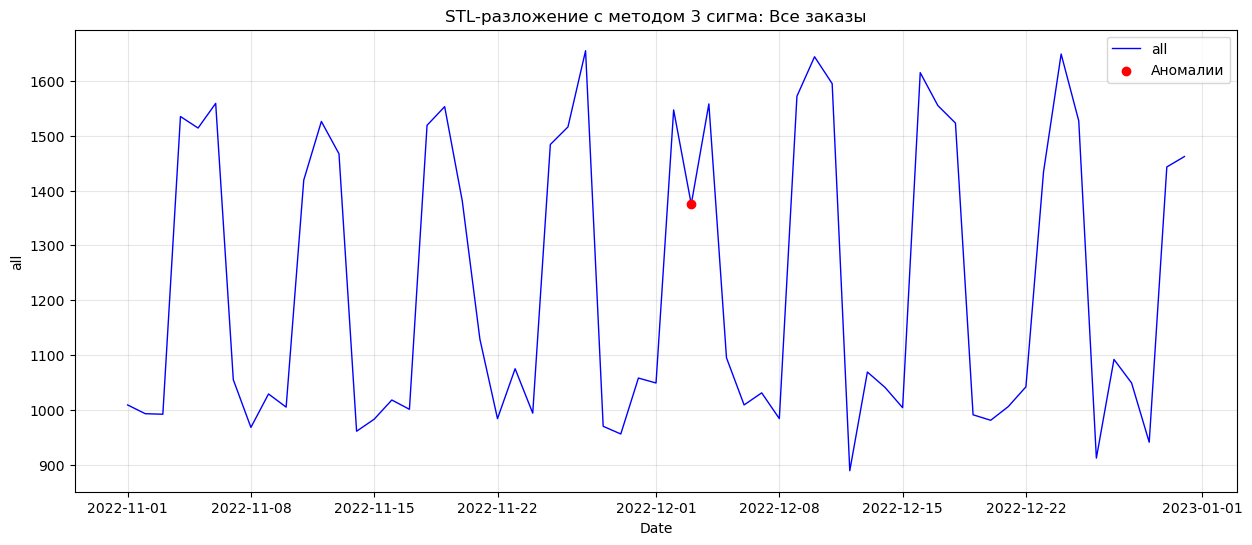

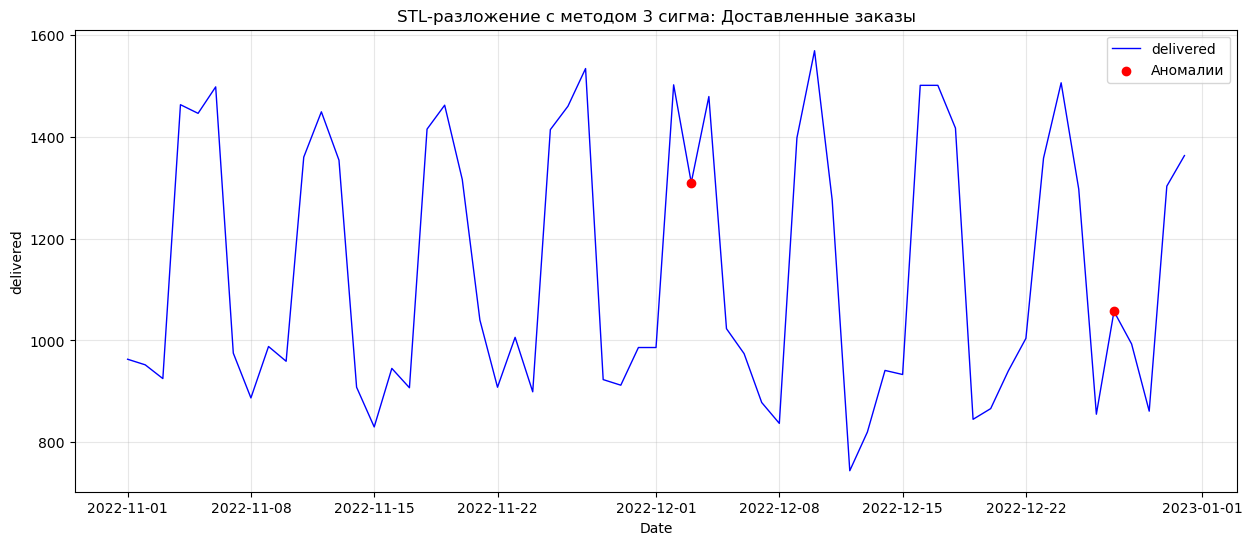

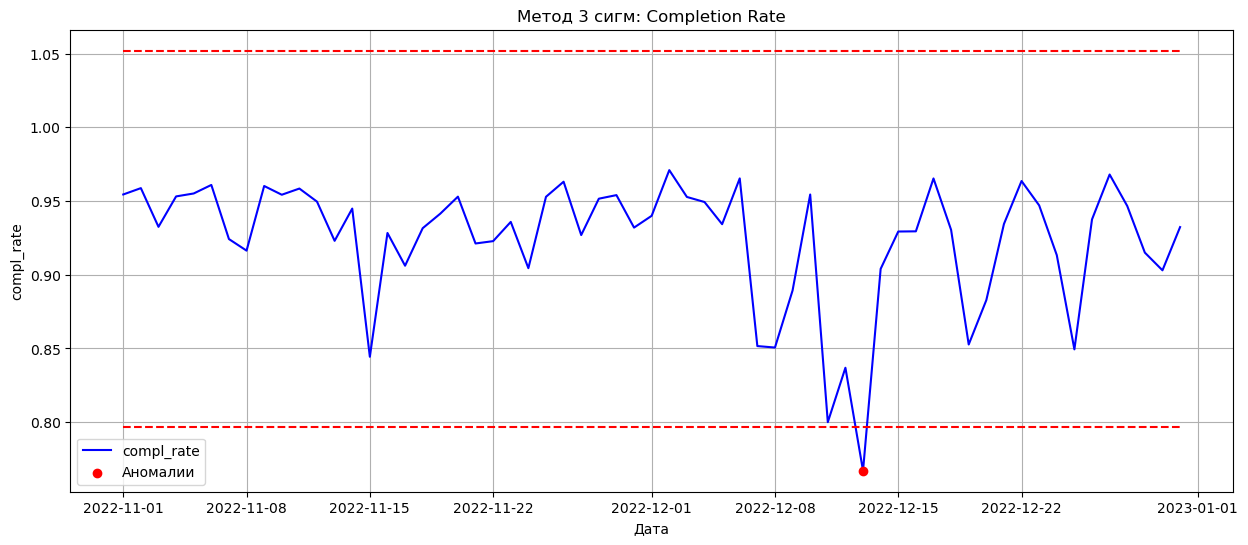

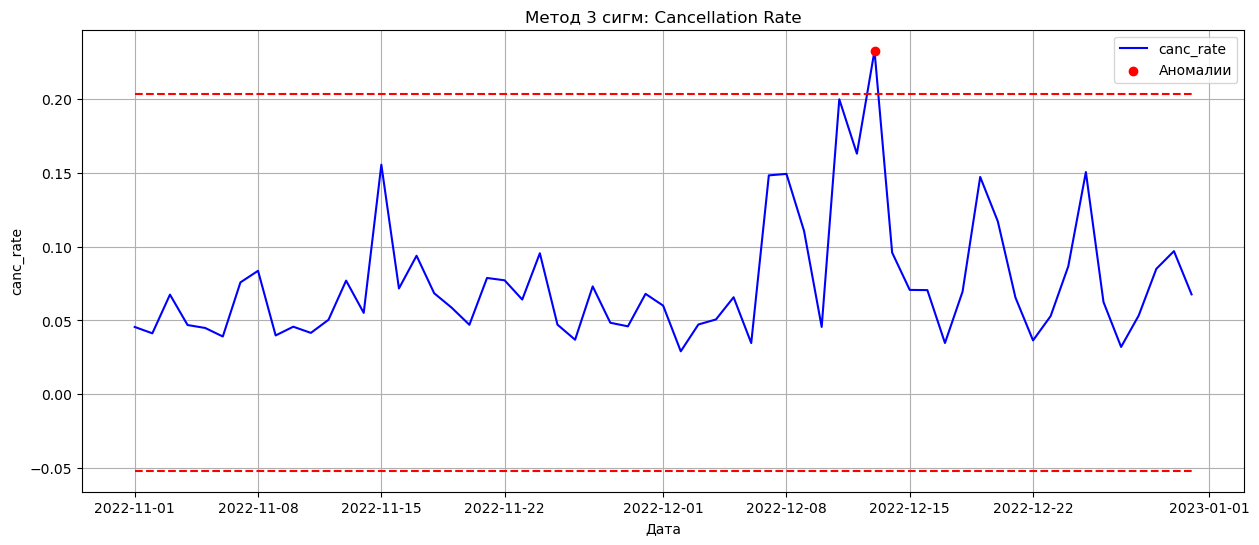

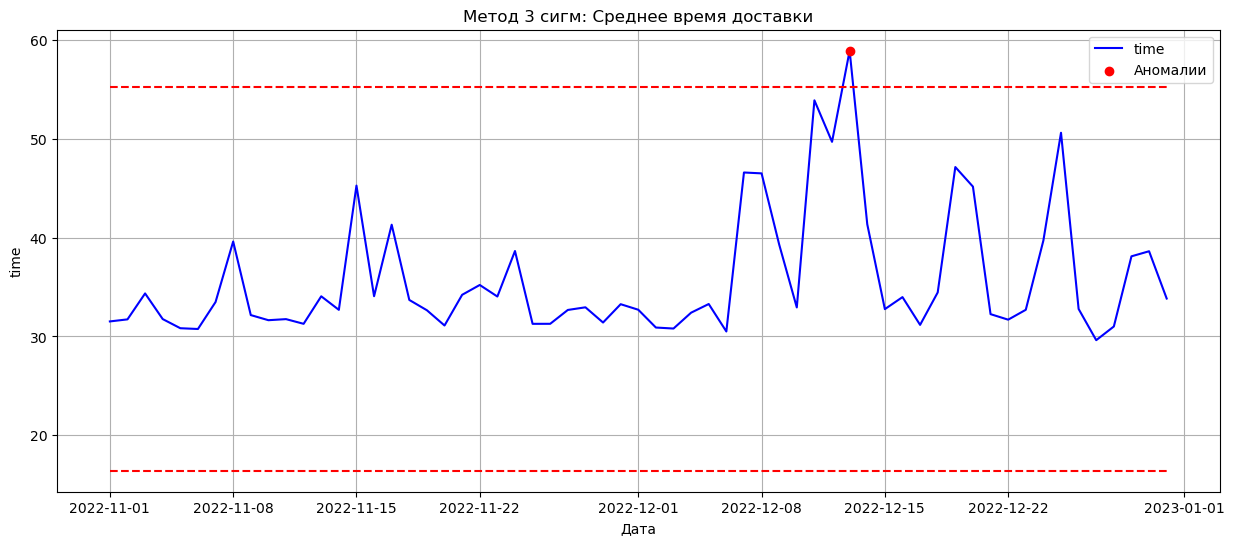

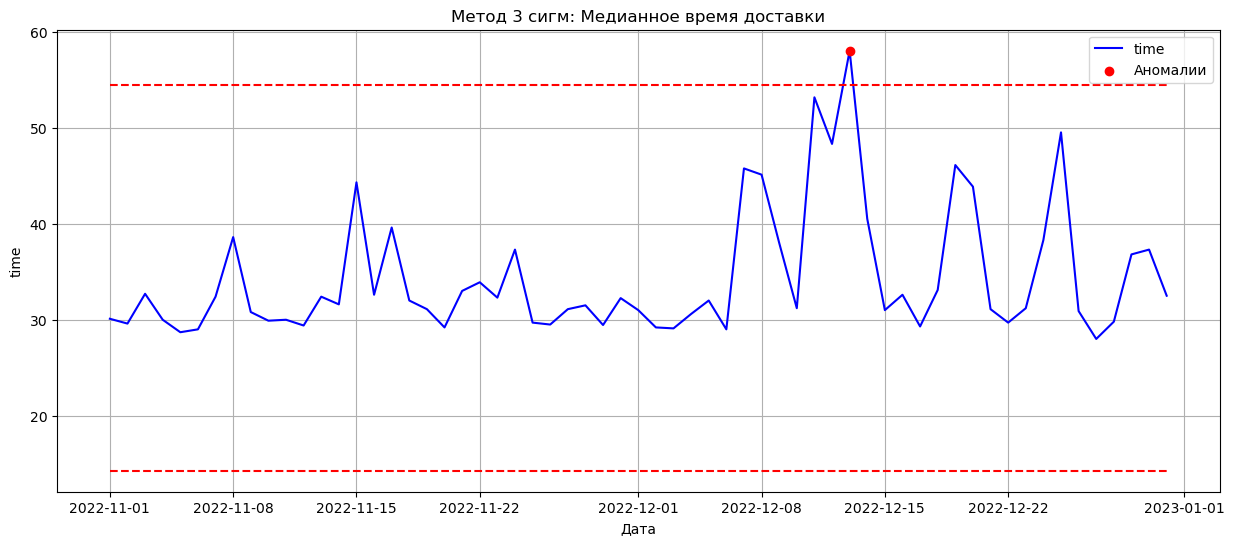

In [49]:
results, anomalies, residuals = get_stl_results_3_sigmas(df_orders_compl, 'date', 'all')
visualization_stl(df_orders_compl, 'all', 'Все заказы', results, anomalies, sigma=3)

results, anomalies, residuals = get_stl_results_3_sigmas(df_orders_compl, 'date', 'delivered')
visualization_stl(df_orders_compl, 'delivered', 'Доставленные заказы', results, anomalies, sigma=3)

visualization_3_sigma(get_3_sigma_cl(df_orders_compl, 'compl_rate'), 'compl_rate', 'Completion Rate')

visualization_3_sigma(get_3_sigma_cl(df_orders_canc, 'canc_rate'), 'canc_rate', 'Cancellation Rate')

visualization_3_sigma(get_3_sigma_cl(df_orders_avg, 'time'), 'time', 'Среднее время доставки')

visualization_3_sigma(get_3_sigma_cl(df_orders_median, 'time'), 'time', 'Медианное время доставки')

Комментарий: 
    По всем заказам обнаружена 1 аномалия, которая отображает нарушение недельного паттерна (до этого наблюдалась недельная сезонность, в середине декабря же вместо стабильного подъема видим падение)
    По доставленным заказом - 2 аномалии (поведение аналогично всем заказам)
    По остальным метрикам (Completion Rate, Canvellation Rate и время доставки) обнаружена 1 аномалия, отображающая резкое увеличение.

#### 3. Поиск причин аномального поведения (шаг 1) — 3 балла
Разложим метрики, в которых обнаружены аномалии, на составляющие.

Визуализируйте:
- Отмены в разрезе причин (абсолютная метрика);
- Длительность этапов, из которых складывается итоговая продолжительность доставки (time_to_assign_courier_min, actual_preparation_time_min, travel_time_min). Берите среднее или медиану на ваш выбор.

Есть ли какие-нибудь закономерности?

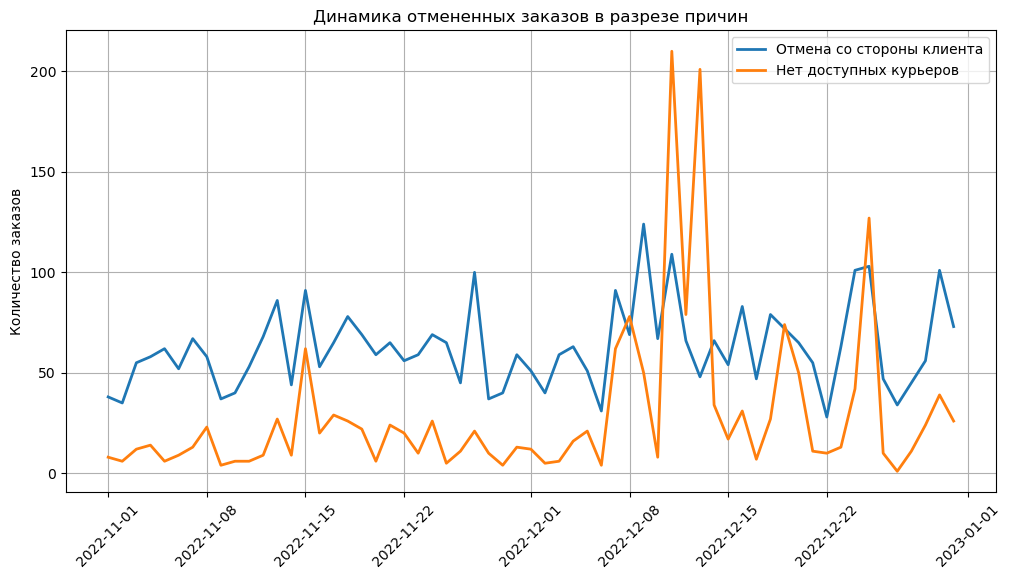

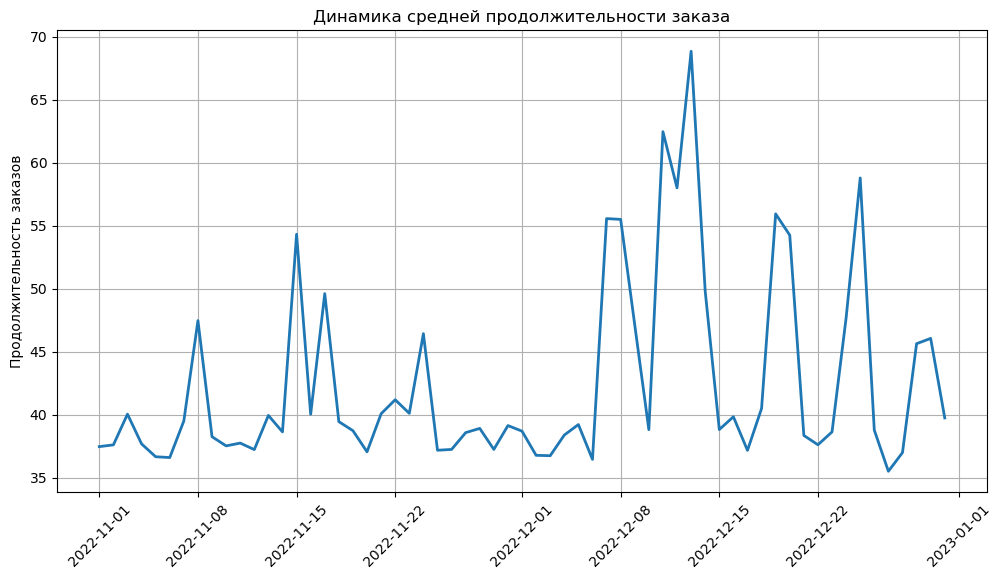

In [51]:
df_cancellations = df_orders.copy()
df_cancellations = df_cancellations[df_cancellations['status'] == 'cancelled']
df_cancellations = df_cancellations.groupby(['date', 'cancellation_reason'])['order_id'].nunique().reset_index()

plt.figure(figsize = (12, 6))

df_cancell_user = df_cancellations[df_cancellations['cancellation_reason'] == 'Cancelled by user']
df_cancell_other = df_cancellations[df_cancellations['cancellation_reason'] == 'No courier available']

plt.plot(df_cancell_user['date'], df_cancell_user['order_id'], label='Отмена со стороны клиента', linewidth=2)
plt.plot(df_cancell_other['date'], df_cancell_other['order_id'], label='Нет доступных курьеров', linewidth=2)
plt.title('Динамика отмененных заказов в разрезе причин')
plt.ylabel('Количество заказов')
plt.legend()
plt.xticks(rotation = 45)
plt.grid()
plt.show()

df_orders['total_time_min'] = df_orders['time_to_assign_courier_min'] + df_orders['actual_preparation_time_min'] + df_orders['travel_time_min']

df_time = df_orders.copy().groupby('date')['total_time_min'].mean().reset_index()

plt.figure(figsize = (12, 6))

plt.plot(df_time['date'], df_time['total_time_min'], linewidth=2)
plt.title('Динамика средней продолжительности заказа')
plt.ylabel('Продолжительность заказов')
plt.xticks(rotation = 45)
plt.grid()
plt.show()

Комментарий: Да, видна закономерность. Например, примерно в середине декабря увеличилась продолжительность заказа, а также возросло количество отмен, связанных с отсутствием курьеров, что может свидетельствовать о высокой нагрузке

#### 4. Поиск причин аномального поведения (шаг 2) — 3 балла
Постройте динамику метрик, в которых обнаружены аномалии, по базовым срезам (можете выбрать что-то одно: Completion Rate или Cancellation Rate, среднее время доставки или медиана времени доставки):
- платформа (iOS, Android);
- район адереса доставки;
- сегмент пользователя (новые / повторные);
- признак промо акции.

Выделяется ли какой-то сегмент, где аномалия выражена сильнее?

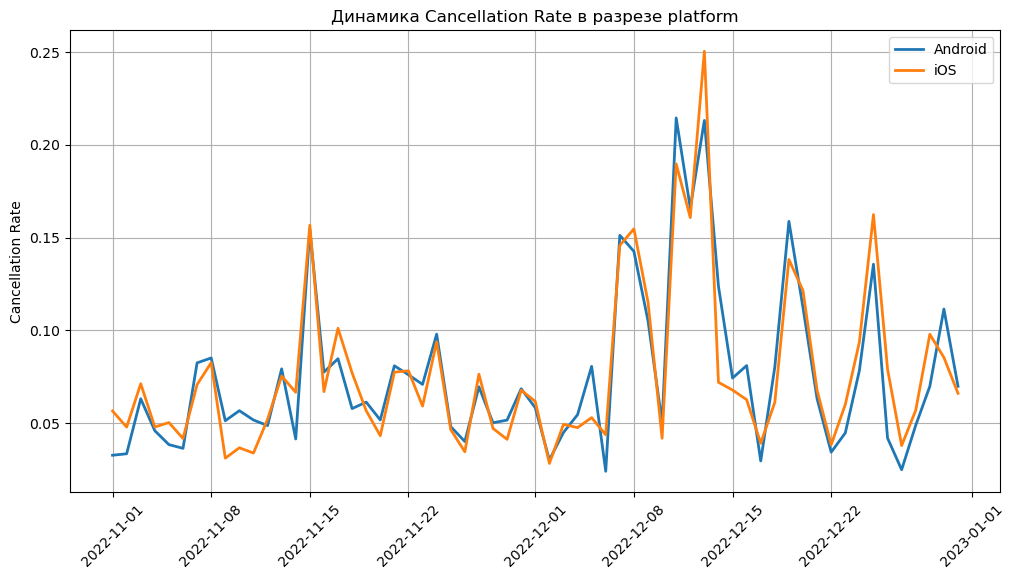

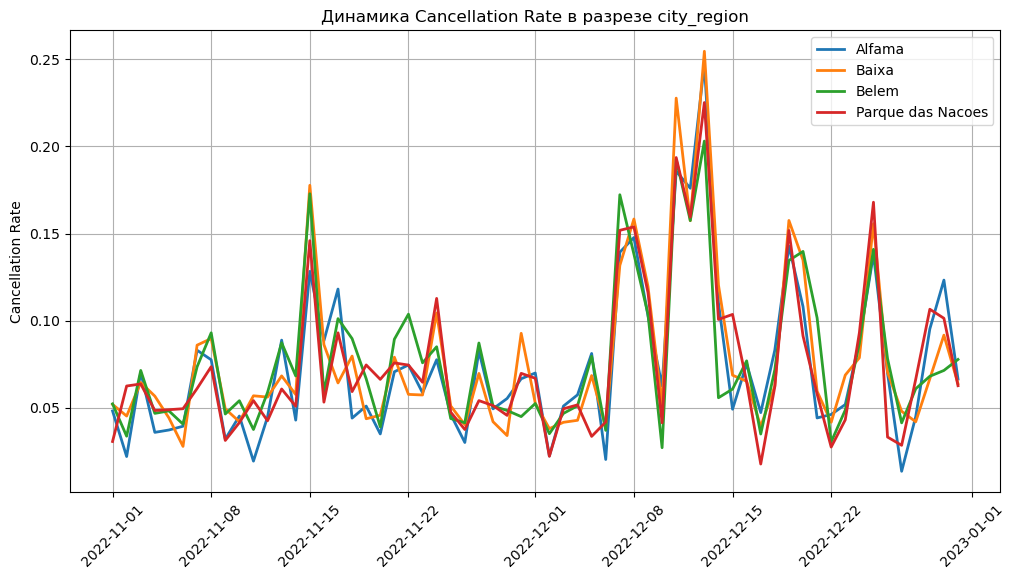

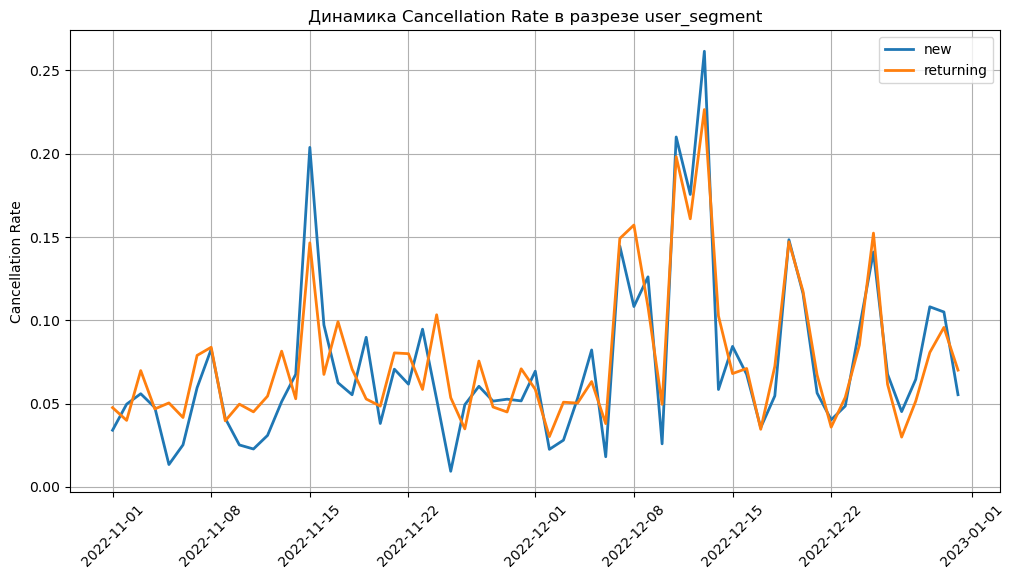

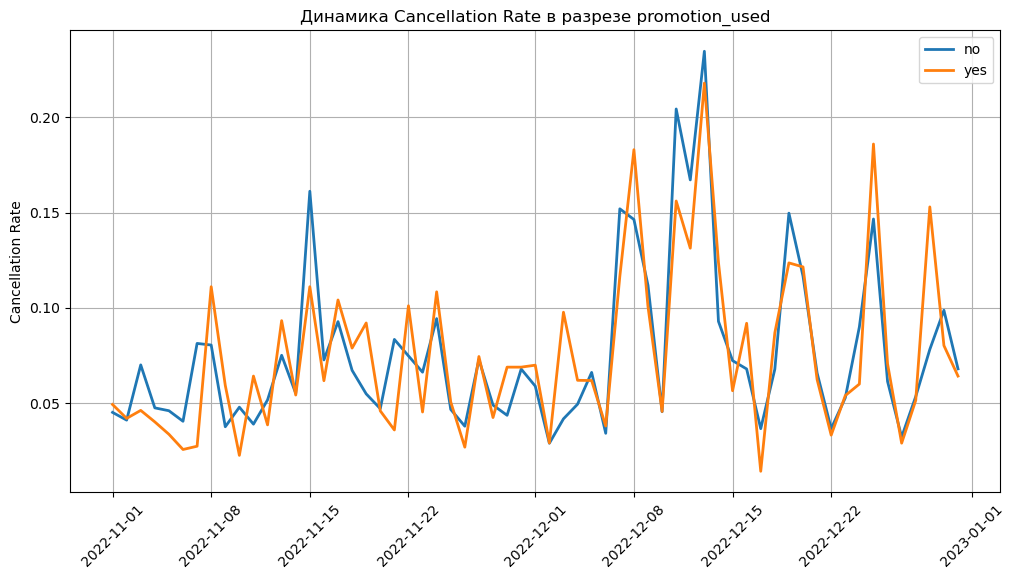

In [53]:
def get_df(df, metric):
    
    df_new = df.copy()
    df_new_all = df_new.groupby(['date', metric])['order_id'].nunique().reset_index()
    df_new_cancelled = df_new[df_new['status'] == 'cancelled']
    df_new_cancelled = df_new_cancelled.groupby(['date', metric])['order_id'].nunique().reset_index()

    df_new = df_new_all.merge(df_new_cancelled, on = ['date', metric])
    df_new.columns = ['date', metric, 'all', 'cancelled']
    df_new['canc_rate'] = df_new['cancelled'] / df_new['all']
    df_new = df_new.drop(columns = ['all', 'cancelled'])
    
    return df_new

def visualization(df, metric):
    
    plt.figure(figsize = (12, 6))
    
    for i in df[metric].unique():
        
        df_plot = df[df[metric] == i]
        plt.plot(df_plot['date'], df_plot['canc_rate'], label=i, linewidth=2)
    
    plt.title(f'Динамика Cancellation Rate в разрезе {metric}')
    plt.ylabel('Cancellation Rate')
    plt.legend()
    plt.xticks(rotation = 45)
    plt.grid()
    plt.show()

df_platform = get_df(df_orders, 'platform')
visualization(df_platform, 'platform')

df_region = get_df(df_orders, 'city_region')
visualization(df_region, 'city_region')

df_segment = get_df(df_orders, 'user_segment')
visualization(df_segment, 'user_segment')

df_promo = get_df(df_orders, 'promotion_used')
visualization(df_promo, 'promotion_used')

Комментарий: Нет, в целом на всех графиках распределение похожее, аномалия не выделена

#### 5. Поиск причин аномального поведения (шаг 3) — 3 балла

Постройте динамику структуры заказов в разрезе сегментов:
- доля заказов по платформам;
- доля заказов по регионам города;
- доля заказов по сегменту пользователя;
- доля заказов по признаку промо акции.

Сравните даты аномалий с динамикой долей. Может ли изменение структуры объяснить падение метрик?

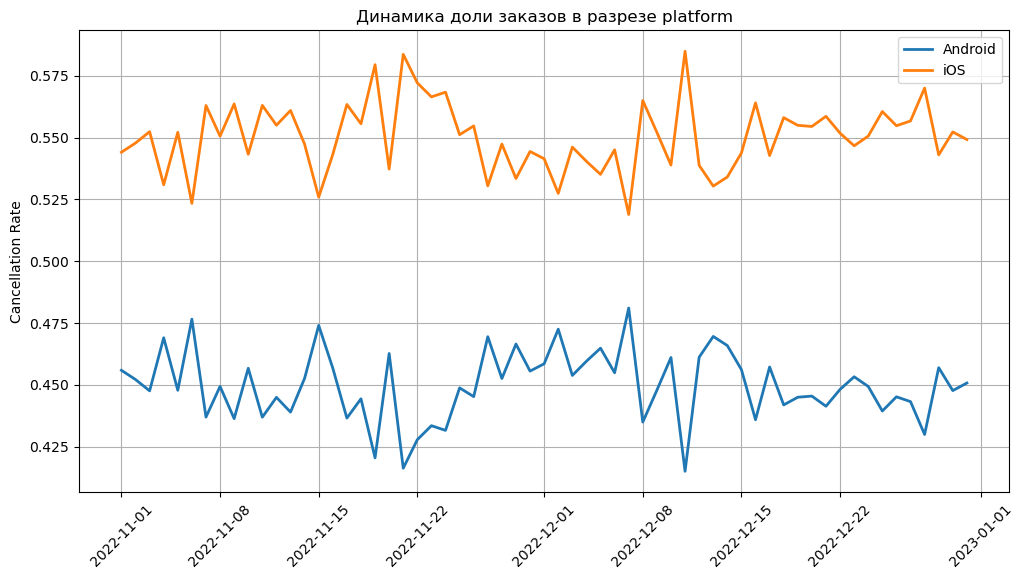

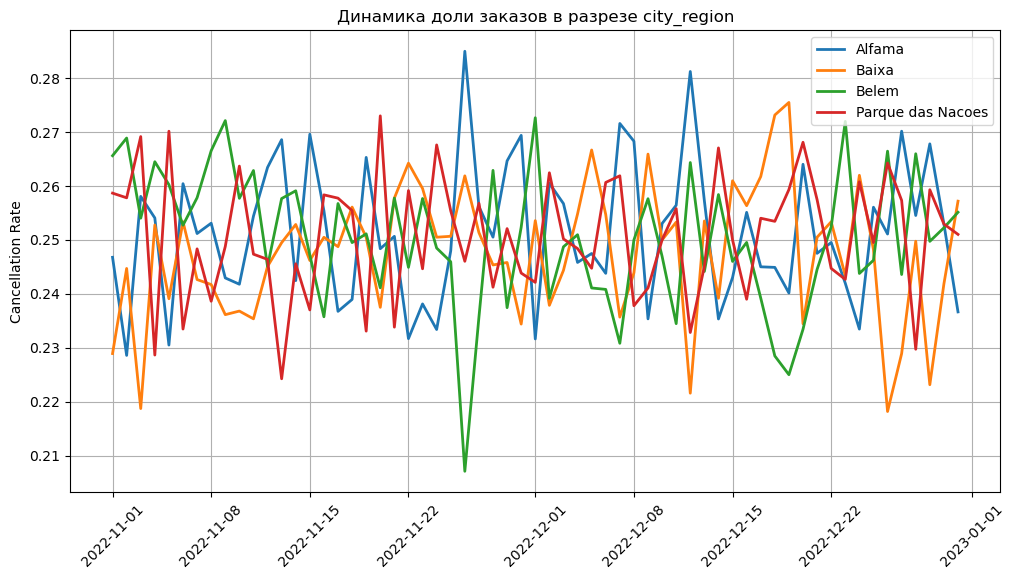

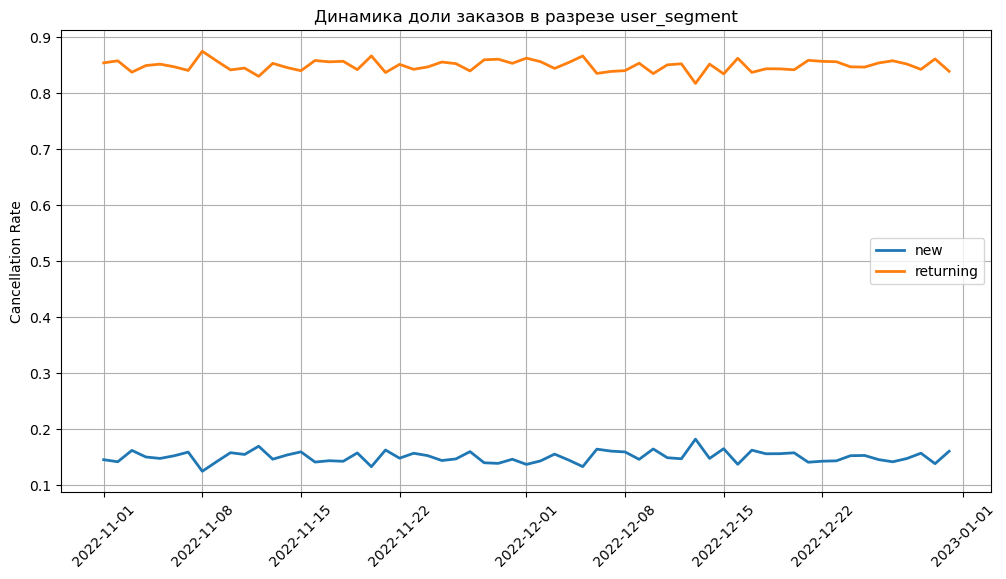

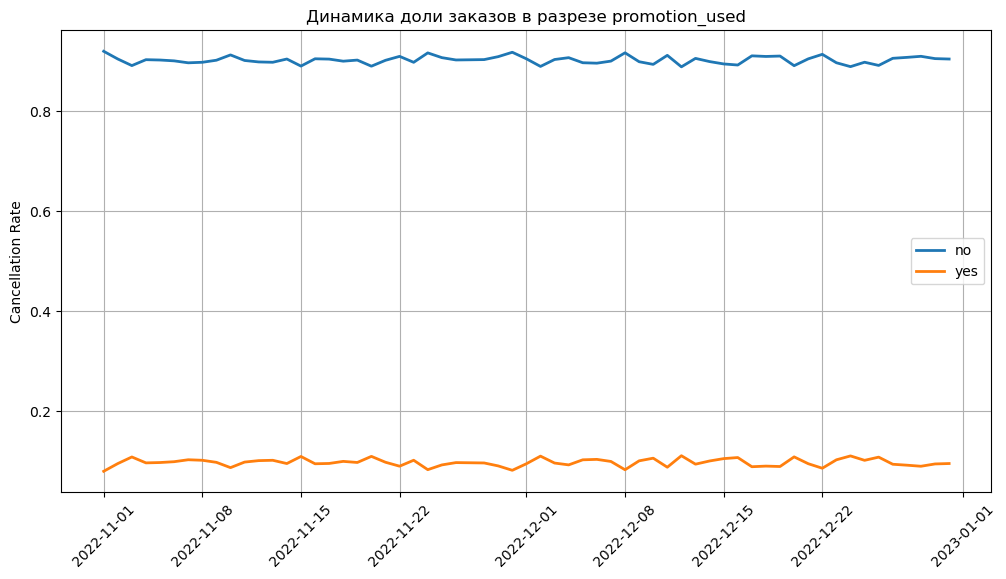

In [55]:
def get_new_df(df, metric):
    
    df_new = df.copy()
    all_orders = df_new.groupby('date')['order_id'].nunique().reset_index()
    all_orders.columns = ['date', 'all_orders']
    
    df_new = df_new.groupby(['date', metric])['order_id'].nunique().reset_index()
    df_new = df_new.merge(all_orders, on = 'date')
    df_new['percentage'] = df_new['order_id'] / df_new['all_orders']
        
    return df_new
        
def visualization(df, metric):
    
    plt.figure(figsize = (12, 6))
    
    for i in df[metric].unique():
        
        df_plot = df[df[metric] == i]
        plt.plot(df_plot['date'], df_plot['percentage'], label=i, linewidth=2)
    
    plt.title(f'Динамика доли заказов в разрезе {metric}')
    plt.ylabel('Cancellation Rate')
    plt.legend()
    plt.xticks(rotation = 45)
    plt.grid()
    plt.show()

df_platform = get_new_df(df_orders, 'platform')
visualization(df_platform, 'platform')

df_region = get_new_df(df_orders, 'city_region')
visualization(df_region, 'city_region')

df_segment = get_new_df(df_orders, 'user_segment')
visualization(df_segment, 'user_segment')

df_promo = get_new_df(df_orders, 'promotion_used')
visualization(df_promo, 'promotion_used')

Комментарий:
Анализ динамики долей заказов по платформам, регионам, сегментам пользователей и промо-акциям 
не выявил значительных изменений структуры в периоды аномалий.

#### 6. Поиск причин аномального поведения (шаг 4) — 3 балла
Разложение метрик на срезы не принесло результатов. Может быть причина аномалий лежит вне продукта?

Получите данные о погоде по API за весь анализируемый период по дням. Для этого используйте [Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api?daily=temperature_2m_mean,wind_speed_10m_max,precipitation_sum) от Open-Meteo (регистрация и получение ключа не требуется, по ссылке есть пример запроса на Python).

- Для координат выгрузки возьмите: latitude: 38.736946, longitude: -9.142685;
- Timezone — auto;
- daily значения temperature_2m_mean, precipitation_sum, wind_speed_10m_max.

Соберите датасет с колонками: день, средняя температура воздуха, максимальная скорость ветра, суммарное количество осадков.

In [57]:
! pip install openmeteo-requests
! pip install requests-cache retry-requests numpy pandas

import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

start_date = pd.to_datetime(df_orders['date'].min()).strftime('%Y-%m-%d')
end_date = pd.to_datetime(df_orders['date'].max()).strftime('%Y-%m-%d')

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
 "latitude": 38.736946,
 "longitude": -9.142685,
 "start_date": start_date,
 "end_date": end_date,
 "daily": ["temperature_2m_mean", "wind_speed_10m_max", "precipitation_sum"],
 "timezone": "auto",
}
responses = openmeteo.weather_api(url, params=params)

# # Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(1).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
 start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
 end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
 freq = pd.Timedelta(seconds = daily.Interval()),
 inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["precipitation_sum"] = daily_precipitation_sum

daily_dataframe = pd.DataFrame(data = daily_data)
daily_dataframe

,date,temperature_2m_mean,wind_speed_10m_max,precipitation_sum
0,2022-10-31 23:00:00+00:00,15.119000,16.854767,0.1
1,2022-11-01 23:00:00+00:00,14.552334,14.830076,0.0
2,2022-11-02 23:00:00+00:00,17.060667,21.370783,5.4
3,2022-11-03 23:00:00+00:00,15.206501,17.339897,0.0
4,2022-11-04 23:00:00+00:00,14.098167,12.413477,0.0
...,...,...,...,...
56,2022-12-26 23:00:00+00:00,13.577332,8.788720,0.0
57,2022-12-27 23:00:00+00:00,13.366916,13.551500,0.1
58,2022-12-28 23:00:00+00:00,15.510666,25.120159,2.3
59,2022-12-29 23:00:00+00:00,16.083582,25.864943,0.7


#### 7. Поиск причин аномального поведения (шаг 5) — 3 балла
Объедините датасет метрик, в которых найдены аномалии, с датасетом погоды.    
Для каждой метрики постройте совместные визуализации данных погоды и продуктовой метрики.

Сформулируйте гипотезу — что могло повлиять на падение конверсии в дни аномалий? Как конверсия связана с другими метриками, для которых вы  обнаружили аномальные значения? Какую роль в изменении метрик могла сыграть погода?

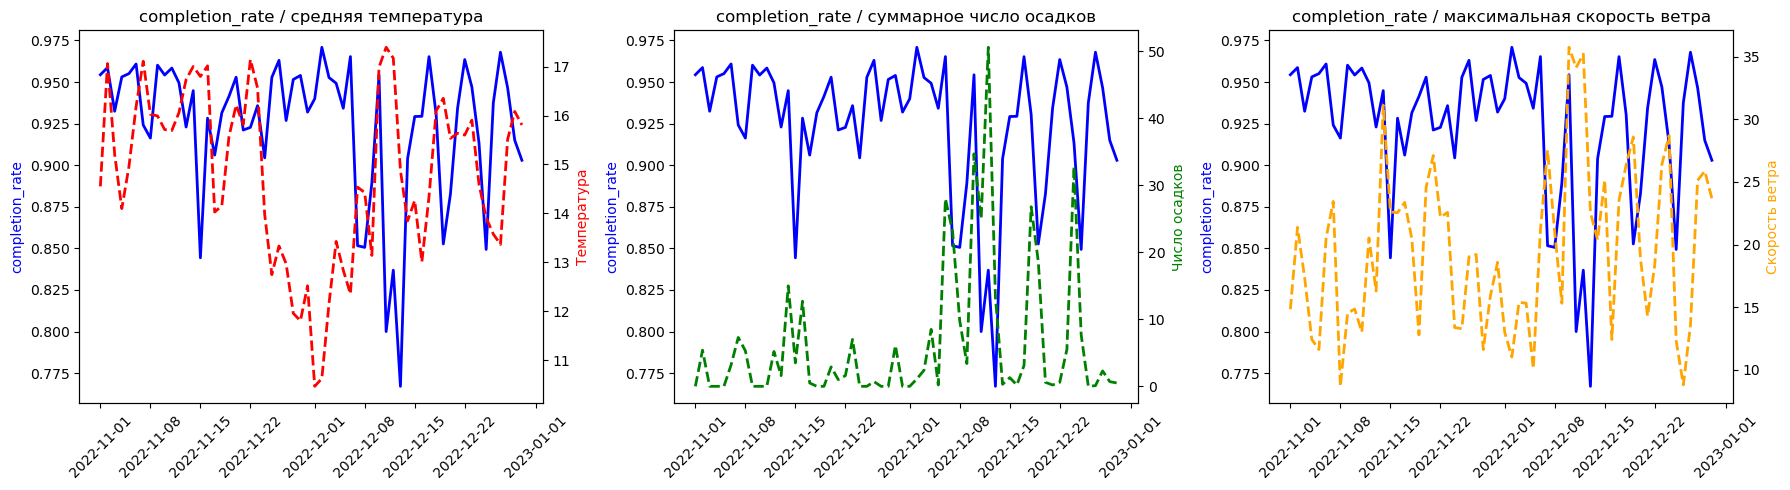

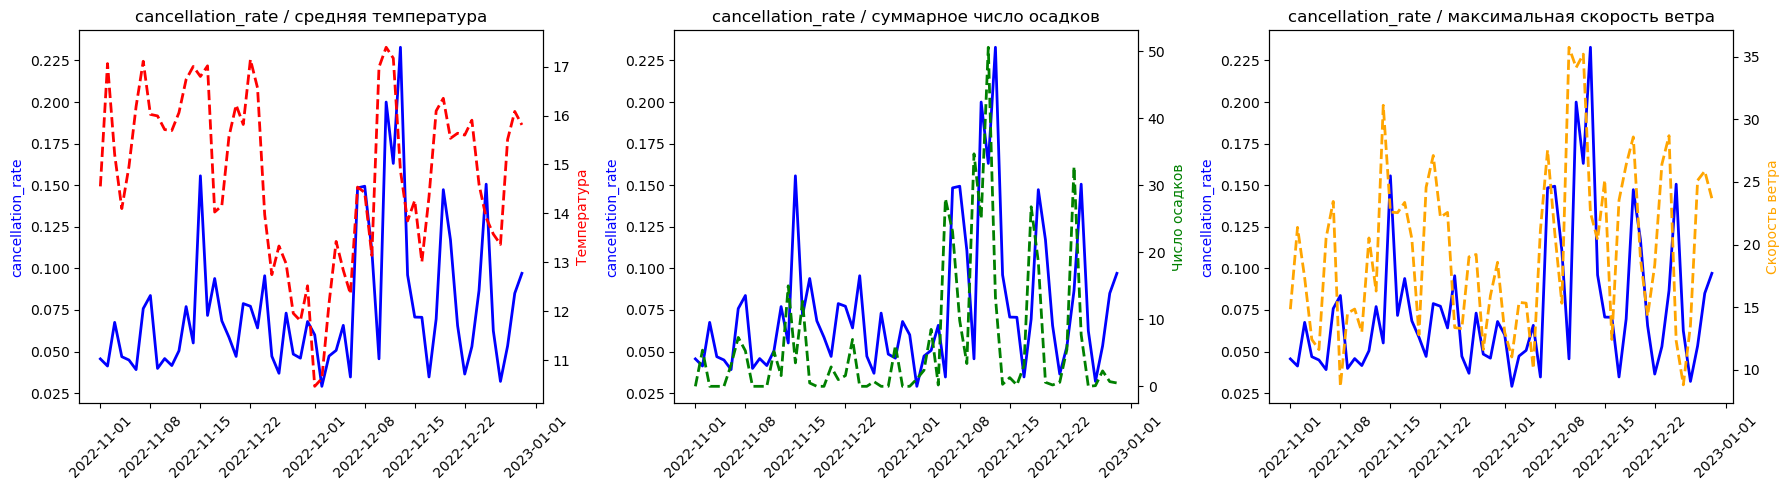

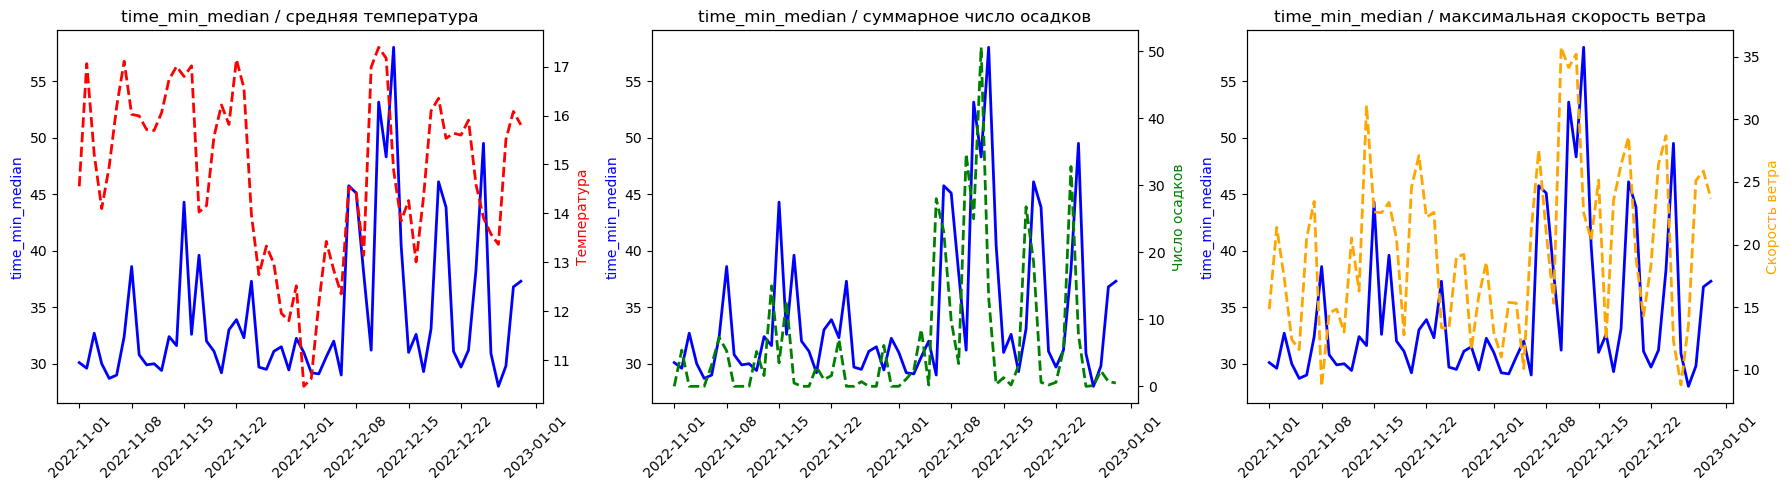

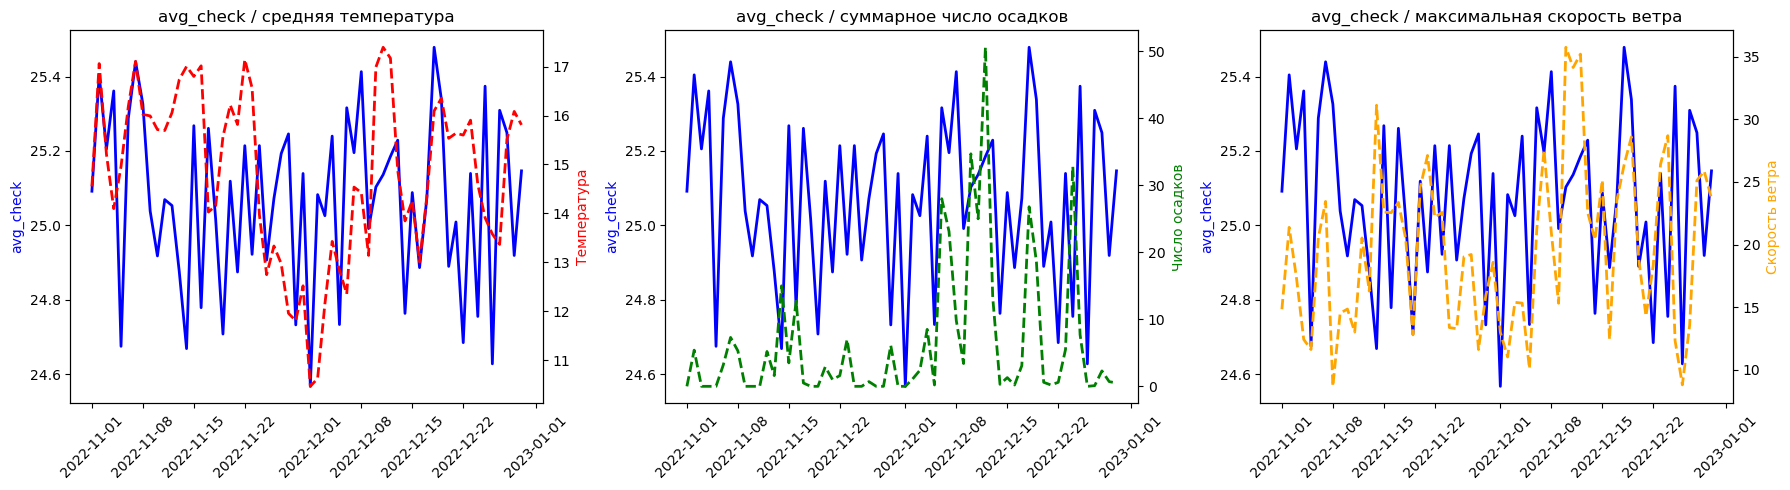

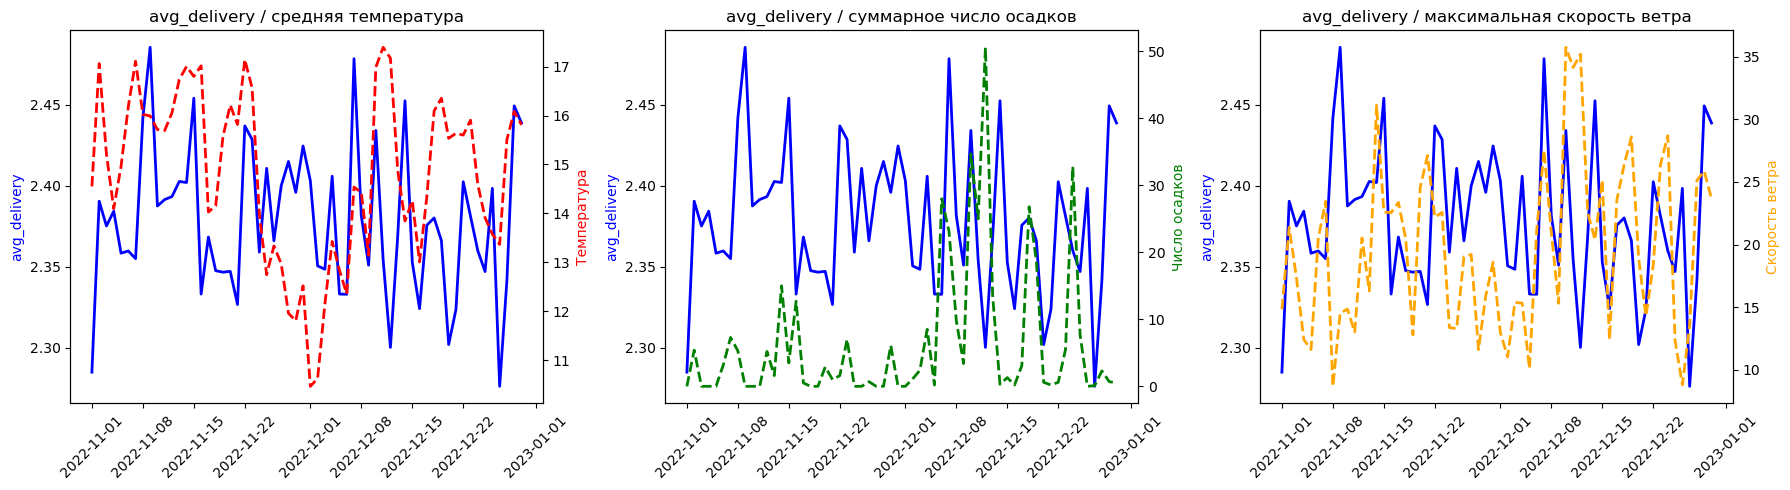

In [59]:
df_metrics = df_orders_compl[['date', 'all', 'delivered', 'compl_rate']].merge(df_orders_canc[['date', 'cancelled', 'canc_rate']], on = 'date')
df_metrics = df_metrics.merge(df_orders_avg[['date', 'time']], on = 'date')
df_metrics.columns = ['date', 'total_orders', 'delivered_orders', 'completion_rate', 'cancelled_orders', 'cancellation_rate', 'time_min_mean']
df_metrics = df_metrics.merge(df_orders_median[['date', 'time']], on = 'date')
df_metrics.columns = ['date', 'total_orders', 'delivered_orders', 'completion_rate', 'cancelled_orders', 'cancellation_rate', 'time_min_mean', 'time_min_median']
df_metrics = df_metrics.merge(df_orders_check[['date', 'avg_check', 'avg_delivery']], on = 'date')

daily_dataframe['date'] = pd.to_datetime(daily_dataframe['date'])
weather_df = daily_dataframe.copy()
weather_df = weather_df.rename(columns = {'date': 'datetime'})
weather_df['date'] = weather_df['datetime'].dt.date
weather_df = weather_df.drop(columns = ['datetime'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

df_metrics['date'] = pd.to_datetime(df_metrics['date'])
df_metrics_weather = df_metrics.merge(weather_df, on = 'date')
df_metrics_weather

def visualization_metrics_weather(df, metric):
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(df['date'], df[metric], label=metric, linewidth=2, color='blue')
    ax0_twin = axes[0].twinx()
    ax0_twin.plot(df['date'], df['temperature_2m_mean'], label='Средняя температура', linewidth=2, color='red', linestyle='--')
    axes[0].set_ylabel(metric, color='blue')
    ax0_twin.set_ylabel('Температура', color='red')
    axes[0].set_title(f'{metric} / средняя температура')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(df['date'], df[metric], label=metric, linewidth=2, color='blue')
    ax1_twin = axes[1].twinx()
    ax1_twin.plot(df['date'], df['precipitation_sum'], label='Суммарное число осадков', linewidth=2, color='green', linestyle='--')
    axes[1].set_ylabel(metric, color='blue')
    ax1_twin.set_ylabel('Число осадков', color='green')
    axes[1].set_title(f'{metric} / суммарное число осадков')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].plot(df['date'], df[metric], label=metric, linewidth=2, color='blue')
    ax2_twin = axes[2].twinx()
    ax2_twin.plot(df['date'], df['wind_speed_10m_max'], label='Максмальная скорость ветра', linewidth=2, color='orange', linestyle='--')
    axes[2].set_ylabel(metric, color='blue')
    ax2_twin.set_ylabel('Скорость ветра', color='orange')
    axes[2].set_title(f'{metric} / максимальная скорость ветра')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

visualization_metrics_weather(df_metrics_weather, 'completion_rate')
visualization_metrics_weather(df_metrics_weather, 'cancellation_rate')
visualization_metrics_weather(df_metrics_weather, 'time_min_median')
visualization_metrics_weather(df_metrics_weather, 'avg_check')
visualization_metrics_weather(df_metrics_weather, 'avg_delivery')

Комментарий:
    По графикам видно, что отмена заказов и время доставки практически полностью повторяют график осадков, из чего можно сделать вывод о том, что в непогоду чаще происходят отмены (возможно, по причине нехватки курьеров)
    
Гипотеза:
В дни аномалий ухудшение погодных условий вызвало увеличение время доставки, что привело к более частым отменам и, как следствие, к увеличению cancellation rate и снижение completion rate

#### 8. Влияние на бизнес-результат — 3 балла
Примените один из методов декомпозиции из разобранных в первом семинаре, чтобы оценить вклад изменения конверсии и числа заказов в изменение числа доставок в декабре относительно ноября (MoM анализ).    

Постройте waterfall диаграмму.

Выпишите дни, которые внесли наибольший вклад в падение среднемесячной конверсии декабря относительно ноября. Пересекаются ли эти даты с датами повышенного числа осадков? Сделайте выводы.

In [81]:
df_8 = df_metrics_weather[(df_metrics_weather['date'].dt.month == 11) | (df_metrics_weather['date'].dt.month == 12)].copy()
monthly_data = df_8.groupby(df_8['date'].dt.to_period('M')).agg({'total_orders': 'sum',
                                                                 'delivered_orders': 'sum'}).reset_index()

monthly_data['completion_rate'] = monthly_data['delivered_orders'] / monthly_data['total_orders']
monthly_data['month'] = monthly_data['date'].dt.to_timestamp()
monthly_data = monthly_data.sort_values('month')

monthly_data['total_orders_lag'] = monthly_data['total_orders'].shift(1)
monthly_data['completion_rate_lag'] = monthly_data['completion_rate'].shift(1)
monthly_data['delivered_orders_lag'] = monthly_data['delivered_orders'].shift(1)

monthly_data['conversion_contribution_rl'] = (monthly_data['total_orders_lag'] * (monthly_data['completion_rate'] - monthly_data['completion_rate_lag']))
monthly_data['volume_contribution_rl'] = (monthly_data['completion_rate'] * (monthly_data['total_orders'] - monthly_data['total_orders_lag']))
monthly_data['delivered_MoM'] = monthly_data['delivered_orders'] - monthly_data['delivered_orders_lag']

monthly_data

,date,total_orders,delivered_orders,completion_rate,month,total_orders_lag,completion_rate_lag,delivered_orders_lag,conversion_contribution_rl,volume_contribution_rl,delivered_MoM
0,2022-11,36308,34084,0.938746,2022-11-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-12,37222,33974,0.912740,2022-12-01,36308.0,0.938746,34084.0,-944.244157,834.244157,-110.0


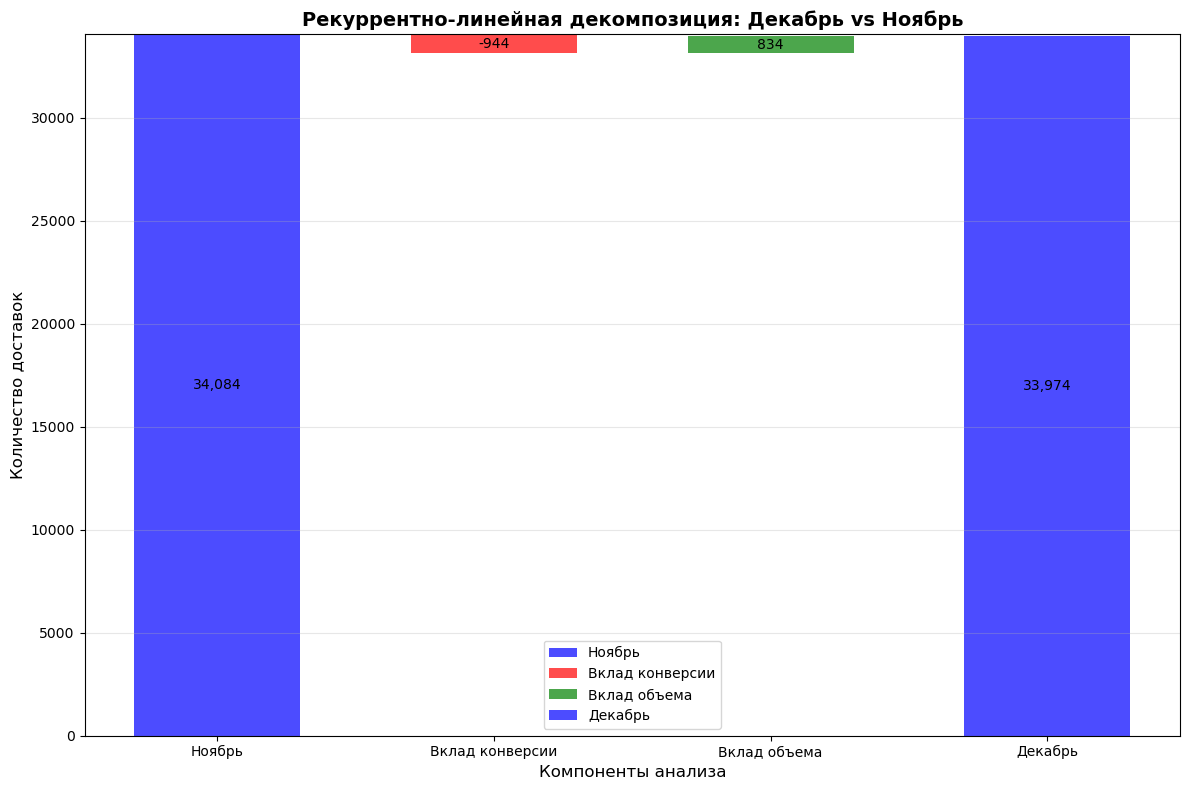

In [117]:
dec_data = monthly_data[monthly_data['month'].dt.month == 12].iloc[0]
nov_data = monthly_data[monthly_data['month'].dt.month == 11].iloc[0]

categories = ['Ноябрь', 'Вклад конверсии', 'Вклад объема', 'Декабрь']
values = [nov_data['delivered_orders'], dec_data['conversion_contribution_rl'], dec_data['volume_contribution_rl'], dec_data['delivered_orders']]

fig, ax = plt.subplots(figsize=(12, 8))

cumulative = [values[0]]
for i in range(1, len(values)-1):
    cumulative.append(cumulative[-1] + values[i])
cumulative.append(values[3])

x_pos = range(len(categories))
width = 0.6

ax.bar(x_pos[0], values[0], width, color='blue', alpha=0.7, label='Ноябрь')
ax.bar(x_pos[1], values[1], width, bottom=cumulative[0], color='green' if values[1] >= 0 else 'red', alpha=0.7, label='Вклад конверсии')
ax.bar(x_pos[2], values[2], width, bottom=cumulative[1], color='green' if values[2] >= 0 else 'red', alpha=0.7, label='Вклад объема')
ax.bar(x_pos[3], values[3], width, color='blue', alpha=0.7, label='Декабрь')

for i, (cat, val, cum_val) in enumerate(zip(categories, values, cumulative)):

    if i == 0 or i == 3:
        y_text = val / 2
    else:
        y_text = cumulative[i-1] + val / 2
    
    ax.text(x_pos[i], y_text, f'{int(val):,}', ha='center', va='center')

plt.title('Рекуррентно-линейная декомпозиция: Декабрь vs Ноябрь', fontsize=14, fontweight='bold')
plt.ylabel('Количество доставок', fontsize=12)
plt.xlabel('Компоненты анализа', fontsize=12)
plt.xticks(x_pos, categories)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

In [161]:
nov_data_daily = df_metrics_weather[df_metrics_weather['date'].dt.month == 11].copy()
dec_data_daily = df_metrics_weather[df_metrics_weather['date'].dt.month == 12].copy()

nov_data_daily['conversion_rate'] = nov_data_daily['delivered_orders'] / nov_data_daily['total_orders']
dec_data_daily['conversion_rate'] = dec_data_daily['delivered_orders'] / dec_data_daily['total_orders']

nov_avg_conversion = nov_data_daily['conversion_rate'].mean()
dec_avg_conversion = dec_data_daily['conversion_rate'].mean()

daily_analysis = dec_data_daily[['date', 'total_orders', 'delivered_orders', 'conversion_rate', 'precipitation_sum']].copy()
daily_analysis['conversion_contribution'] = (daily_analysis['conversion_rate'] - nov_avg_conversion) / len(daily_analysis)

conversion = daily_analysis[daily_analysis['conversion_contribution'] < 0]['date'].unique()
precipitation = daily_analysis[daily_analysis['precipitation_sum'] > 1]['date'].unique()
count = 0

for i in range(len(conversion)):
    if conversion[i] in precipitation:
        count += 1
print(count / len(conversion) * 100)

61.111111111111114


Комментарий: Примерно 61% дат, которые внесли наибольший вклад в падение среднемесячной конверсии декабря относительно ноября, пересекаются с датами с повышенным числом осадков.

####  9. Анализ 24/7 — 3 балла

Одним из распространенных разрезов анализа метрик продуктов с внутринедельной сезонностью является разложение по дням недели и часам.

Постройте матрицу 24/7 (часы - дни недели) для ноября и декабря (в ячейку матрицы должно попасть агрегированное значение метрики для дня недели и часа), но перед этим очистите декабрьские значения от аномалий — для стабильной оценки нам нужны метрики без влияния экстремальной погоды.

Визуализацию стройте для:
- Числа заказов (всех);
- Completion Rate;
- Среднего или медианного времени доставки.

Подумайте, почему в определенные часы / дни недели мы наблюдаем падение конверсии? Как меняются остальные метрики?    
При ответе опирайтесь на статистические понятия — в какие-то часы просадка или, напротив, слишком высокая конверсия может быть не закономерностью, а случайностью из-за эффекта низкой базы в это время.

In [217]:
precipitation_threshold = df_metrics_weather['precipitation_sum'].quantile(0.95)
temperature_threshold_high = df_metrics_weather['temperature_2m_mean'].quantile(0.95)
temperature_threshold_low = df_metrics_weather['temperature_2m_mean'].quantile(0.05)
wind_threshold = df_metrics_weather['wind_speed_10m_max'].quantile(0.95)

normal_weather_data = df_metrics_weather[
    (df_metrics_weather['precipitation_sum'] <= precipitation_threshold) &
    (df_metrics_weather['temperature_2m_mean'] <= temperature_threshold_high) &
    (df_metrics_weather['temperature_2m_mean'] >= temperature_threshold_low) &
    (df_metrics_weather['wind_speed_10m_max'] <= wind_threshold)
]

normal_weather_dates = list(normal_weather_data['date'])
normal_orders_data = df_orders[df_orders['date'].isin(normal_weather_dates)].copy()

normal_orders_data['hour'] = normal_orders_data['order_time'].dt.hour
normal_orders_data['day_of_week'] = normal_orders_data['order_time'].dt.dayofweek

def create_hourly_matrices_cleaned(df, month):

    month_data = df[df['order_time'].dt.month == month].copy()
    orders_matrix = month_data.groupby(['hour', 'day_of_week'])['order_id'].nunique().reset_index()
    delivered_orders = month_data[month_data['status'] == 'delivered']
    cr_matrix = (delivered_orders.groupby(['hour', 'day_of_week'])['order_id'].nunique() / month_data.groupby(['hour', 'day_of_week'])['order_id'].nunique()).reset_index()
    delivery_time_matrix = delivered_orders.groupby(['hour', 'day_of_week'])['total_time_min'].median().reset_index()
    
    return orders_matrix, cr_matrix, delivery_time_matrix

nov_orders_clean, nov_cr_clean, nov_time_clean = create_hourly_matrices_cleaned(normal_orders_data, 11)
dec_orders_clean, dec_cr_clean, dec_time_clean = create_hourly_matrices_cleaned(normal_orders_data, 12)

Визуализация матрицы 24/7: Количество заказов


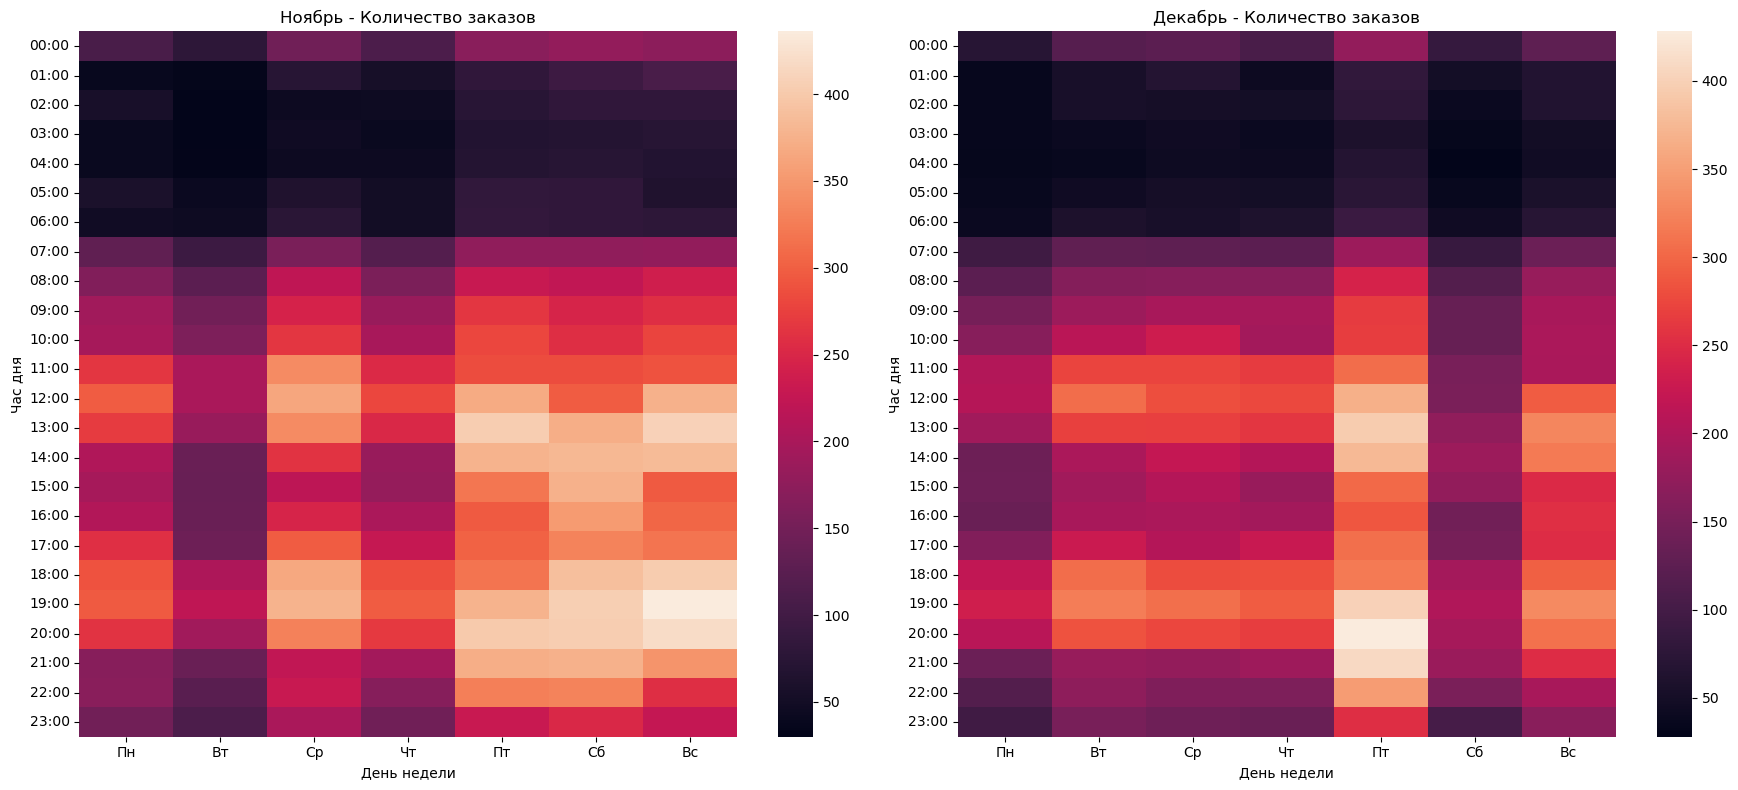


Визуализация матрицы 24/7: Completion Rate


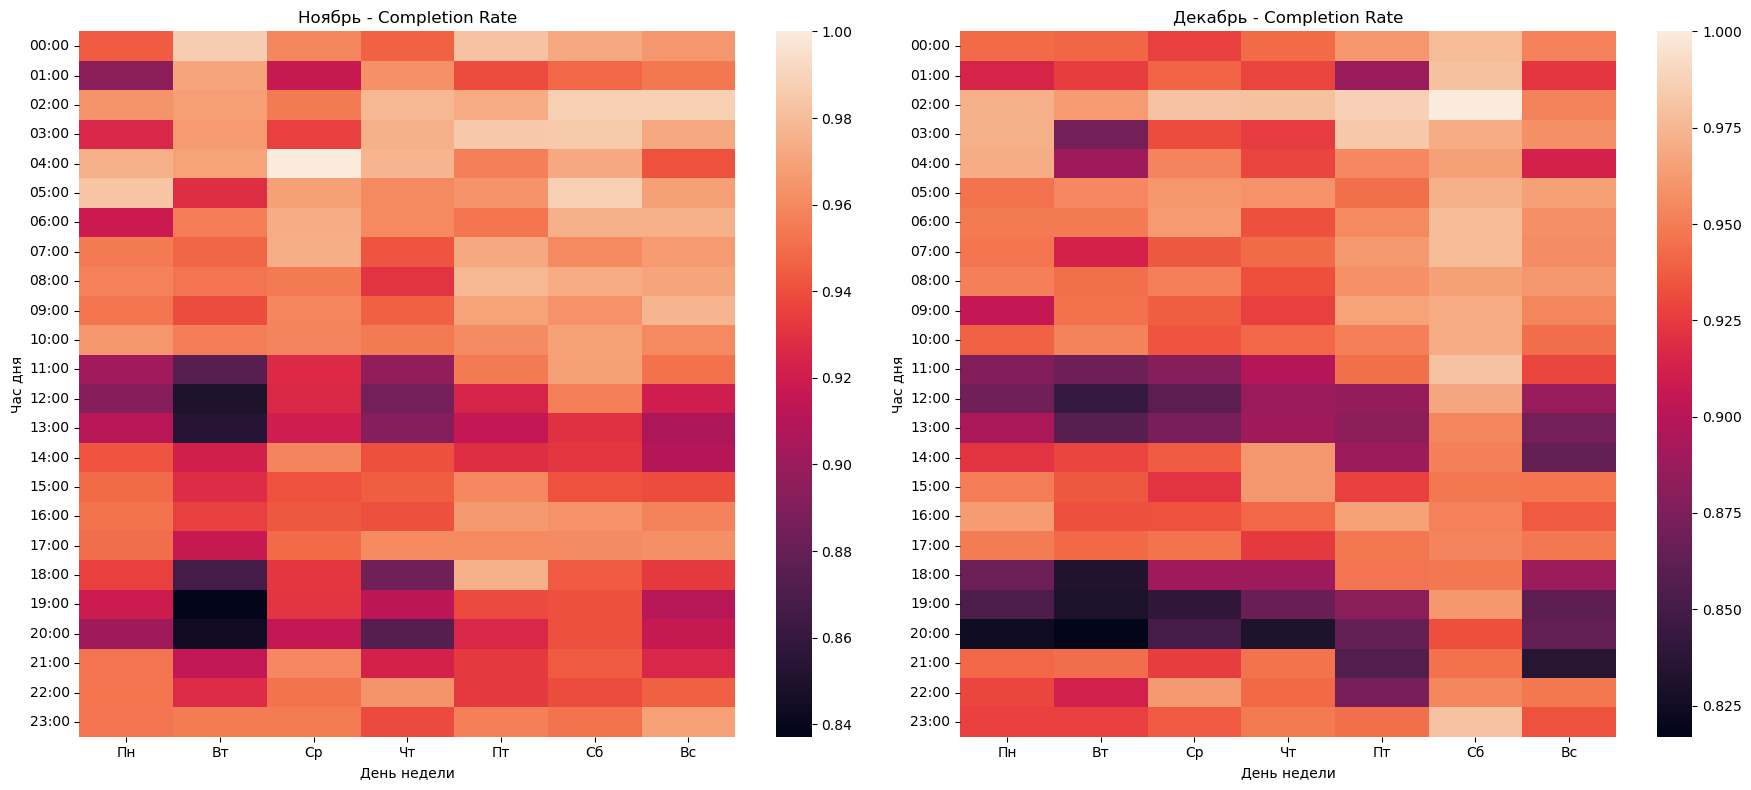


Визуализация матрицы 24/7: Время доставки


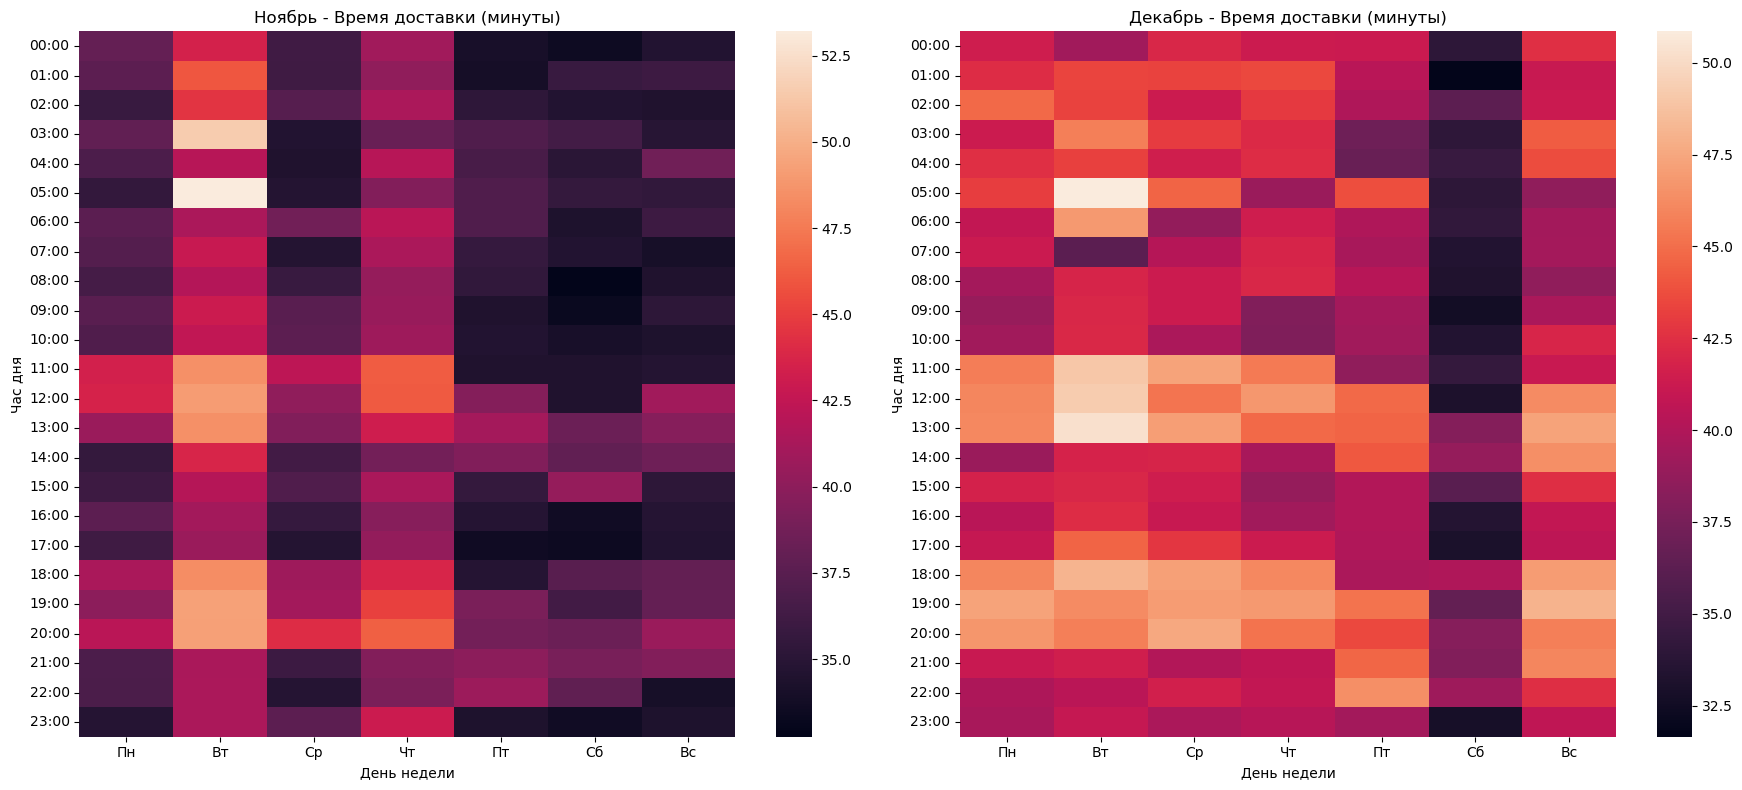

In [219]:
def plot_24_7_comparison(nov_matrix, dec_matrix, title):
    
    days_of_week = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    hours = [f'{h:02d}:00' for h in range(24)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(nov_matrix, ax=ax1, xticklabels=days_of_week, yticklabels=hours)
    ax1.set_title(f'Ноябрь - {title}')
    ax1.set_xlabel('День недели')
    ax1.set_ylabel('Час дня')
    ax1.tick_params(axis='x')
    ax1.tick_params(axis='y')
    
    sns.heatmap(dec_matrix, ax=ax2, xticklabels=days_of_week, yticklabels=hours)
    ax2.set_title(f'Декабрь - {title}')
    ax2.set_xlabel('День недели')
    ax2.set_ylabel('Час дня')
    ax2.tick_params(axis='x')
    ax2.tick_params(axis='y')
    
    plt.tight_layout()
    plt.show()


nov_orders_clean_pivot = nov_orders_clean.pivot(index='hour', columns='day_of_week', values='order_id')
dec_orders_clean_pivot = dec_orders_clean.pivot(index='hour', columns='day_of_week', values='order_id')

nov_cr_clean_pivot = nov_cr_clean.pivot(index='hour', columns='day_of_week', values='order_id')
dec_cr_clean_pivot = dec_cr_clean.pivot(index='hour', columns='day_of_week', values='order_id')

nov_time_clean_pivot = nov_time_clean.pivot(index='hour', columns='day_of_week', values='total_time_min')
dec_time_clean_pivot = dec_time_clean.pivot(index='hour', columns='day_of_week', values='total_time_min')

print("Визуализация матрицы 24/7: Количество заказов")
plot_24_7_comparison(nov_orders_clean_pivot, dec_orders_clean_pivot, 'Количество заказов')

print("\nВизуализация матрицы 24/7: Completion Rate")
plot_24_7_comparison(nov_cr_clean_pivot, dec_cr_clean_pivot, 'Completion Rate')

print("\nВизуализация матрицы 24/7: Время доставки")
plot_24_7_comparison(nov_time_clean_pivot, dec_time_clean_pivot, 'Время доставки (минуты)')

Комментарий: По графикам видно, что в основном конверсия снижается по вторникам и четвергам (11:00-13:00 и 18:00-20:00)
Это может быть связано с тем, что время доставки в это время увеличивается
Помимо указанных дней конверсия падает также в понедельник и в воскресенье, но если в воскресенье растет число заказов, то в понедельник слишком высокая конверсия может быть не закономерностью, а случайностью из-за эффекта низкой базы в это время
В декабре моэно выделить будние дни и воскресенье, в эти дни растет число заказов

####   10. Предложение по улучшению продукта — 3 балла
Базовым подходом для оптимизации работы в часы пик в доставке является динамическое ценообразование. В продукте эта механика еще не реализована. Вы смотрите на данные и решаете, что это отличная инициатива для планирования следующего квартала.

*Динамическое ценообразование помогает не только сглаживать часы повышенного спроса, но и регулировать работу продукта при внешних влияниях, когда пик спроса предсказать невозможно. В данном кейсе мы не рассматриваем такие решения, т.к. не стремимся написать алгоритм динамического прайсинга, а хотим провести базовое исследование проблем и поиск инициативы под быструю реализацию и тест. Поэтому в дальнейших заданиях речь идет исключительно о часах повышенного спроса, очищенных от аномалий.*

Чтобы протестировать гипотезу, достаточно простого подхода — увеличивать стоимость доставки на фиксированный процент (например, на 20%) в определенные дни недели-часы.

- На основе построенных в предыдущем задании матриц, предложите, в какие дни недели / часы вы порекомендуете увеличить стоимость доставки.
- Для каждого месяца рассчитайте долю заказов от общего числа, который будет иметь повышенную стоимость, согласно предложенным вами правилам повышения.

Комментарий: для увеличения стоимости доставки я бы рекомендовала в ноябре вторник и четверг (11:00, 12:00, 13:00, 18:00, 19:00, 20:00), в декабре - понедельник-четверг (11:00, 12:00, 13:00, 18:00, 19:00, 20:00), пятницу (12:00, 13:00, 14:00, 19:00, 20:00, 21:00, 22:00) и воскресенье (12:00, 13:00, 14:00, 18:00, 19:00, 20:00, 21:00)

In [221]:
premium_hours_november = {
    1: [11, 12, 13, 18, 19, 20],
    3: [11, 12, 13, 18, 19, 20]}

premium_hours_december = {
    0: [11, 12, 13, 18, 19, 20],
    1: [11, 12, 13, 18, 19, 20],
    2: [11, 12, 13, 18, 19, 20],
    3: [11, 12, 13, 18, 19, 20],
    4: [12, 13, 14, 19, 20, 21, 22],
    6: [12, 13, 14, 18, 19, 20, 21]}

def calculate_premium_orders_share_detailed(premium_hours, orders_matrix):
    
    total_orders = 0
    premium_orders = 0

    for day in range(7):
        for hour in range(24):
            if hour in orders_matrix.index and day in orders_matrix.columns:
                orders_count = orders_matrix.loc[hour, day]
                total_orders += orders_count
                
                if day in premium_hours and hour in premium_hours[day]:
                    premium_orders += orders_count
                    
    result = premium_orders / total_orders
    
    return result

nov_premium_orders = calculate_premium_orders_share_detailed(premium_hours_november, nov_orders_clean_pivot)
dec_premium_orders = calculate_premium_orders_share_detailed(premium_hours_december, dec_orders_clean_pivot)

print('В ноябре доля заказов с повышенной стоимостью =', nov_premium_orders)
print('В декабре доля заказов с повышенной стоимостью =', dec_premium_orders)

В ноябре доля заказов с повышенной стоимостью = 0.08254771880819367
В декабре доля заказов с повышенной стоимостью = 0.387500433290582


### Часть 2. Дизайн эксперимента

Ваше предложение понравилось команде. Бэклог инициатив собран, время планировать роадмап. Вас просят провести дизайн эксперимента повышения стоимости доставки на 20% в регулярные часы повышенного спроса, чтобы команда поняла, сколько времени понадобится для получения результатов.

#### 1. Формат эксперимента — 3 балла

Выберите и обоснуйте единицу рандомизации теста:
- по-юзерный A/B тест,
- свитчбек по времени (например, 30-минутки);
- региональный A/B тест.

Вы отвечали на тестовой вопрос о такой же инициативе в ДЗ 3, возможно, это поможет определиться.

Ответ: свитчбек по времени подходит лучше всего, поскольку легко учесть сезонность

#### 2. Выбор таргет метрики — 3 балла

H1: Если мы введем динамическую наценку на доставку 20% в часы пик, то Completion Rate вырастет на 2%, а среднее время доставки снизится на 5%, потому что часть пользователей отложит заказ (снижение спроса), а повышенная оплата привлечет больше курьеров на линию (рост предложения).

Предложите таргет-метрику для эксперимента, обоснуйте свой выбор.

*Поскольку в гипотезе упоминаются сразу 2 метрики, и ни одна из них не является guardrail, метрику, которую вы не посчитаете таргетной, все равно будем учитывать в эксперименте как вторичную для принятия решения о результатах.*

Ответ: я бы предложила выбрать Completion rate, поскольку она измерима, объяснима, устойчива

#### 3. Выбор guardrails метрик — 3 балла

Выберите не более 3 guardrails-метрик для эксперимента из списка ниже, обоснуйте свой выбор.

- Доля отмен заказов;
- Доля отмен заказов по причине No courier available;
- Доля отмен заказов по причине Cancelled by user;
- Среднее время на поиск курьера time_to_assign_courier_min;
- Средняя стоимость доставки;
- Средний чек;
- Среднее gross revenue на заказ (average order value + delivery fee).

*Guardrails метрик в тесте может быть больше, но нам важно понять логику ваших рассуждений при ограниченном выборе. Тут нет одного правильного ответа, будем учитывать проработку обоснования при оценке.*

Ответ: я бы выбрала долю отмен заказов, долю отмен заказов по причине No courier available, среднее gross revenue на заказ
Обоснование: доля отмен заказов по причине Cancelled by user - наименее информативна в разрезе выбранных метрик; среднее время на поиск курьера time_to_assign_courier_min - взаимозаменяемая метрика с долей отмен по причине No courier available; средняя стоимость доставки - именно эту метрику мы завышаем в эксперименте; средний чек - может меняться по различным причинам (количество позиций в чеке, наличие скидки/промо и т.п.)

#### 4. Выбор информативных метрик — 3 балла

Выберите не более 3 информативных метрик для эксперимента из списка ниже, обоснуйте свой выбор.

- Доля отмен заказов;
- Доля отмен заказов по причине No courier available;
- Доля отмен заказов по причине Cancelled by user;
- Среднее время на поиск курьера time_to_assign_courier_min;
- Средняя стоимость доставки;
- Средний чек;
- Среднее gross revenue на заказ (average order value + delivery fee).

*Информативных метрик в тесте может быть больше, но нам важно понять логику ваших рассуждений при ограниченном выборе. Тут нет одного правильного ответа, будем учитывать проработку обоснования при оценке.*

Ответ: доля отмен заказов по причине Cancelled by user, среднее время на поиск курьера time_to_assign_courier_min, средний чек
Обоснование: данные метрики наилучшим образом отображают причинно-следственные связи, а также позволяют сегментировать результаты

#### 5. Поправка на множественное сравнение — 3 балла

Перед тем, как приступить к расчету длительности, выберите уровень значимости и мощность, которые будете использовать в расчетах далее. Отталкивайтесь от общепринятых alpha = 0.05 и beta = 0.2.

Для поправки на множественное сравнение можете взять поправку Бонферрони. Не забывайте, что мы корректируем alpha только на число метрик, непосредственно участвующих в принятии решения об успешности теста.

In [ ]:
Ответ: alpha = 0.05 и beta = 0.1

#### 6. Влияние выбросов на длительность экперимента — 3 балла

В исследовательской части мы обнаружили аномальные значения метрик, вызванные внешними факторами. Такое состояние продукта не является целевым и случается достаточно редко.

На примере таргет метрики оцените дисперсию метрики, рассчитанную на значениях декабря полностью и с исключением аномального дня.

Мы проводим эти расчеты в рамках дизайна эксперимента, поэтому в анализе используйте формулу (подсказки по формулам в задании ниже), которую будете применять для расчета длительности (ratio метрика, рассчитанная по единице рандомизации эксперимента).

Сделайте выводы о вариативности метрики при включении / исключении аномалии. Напишите, как разные подходы повлияют на длительность эксперимента и почему. Примите решение, какой из способов расчета будете применять вы в следующих шагах.

In [241]:
def analyze_variance_impact():

    dec_data = df_metrics_weather[df_metrics_weather['date'].dt.month == 12].copy()
    normal_data = dec_data[dec_data['date'] != '2022-12-12']
    
    total_orders = dec_data['total_orders'].sum()
    delivered_orders = dec_data['delivered_orders'].sum()
    p = delivered_orders / total_orders
    var = (p * (1 - p)) / total_orders

    total_orders_normal = normal_data['total_orders'].sum()
    delivered_orders_normal = normal_data['delivered_orders'].sum()
    p_normal = delivered_orders_normal / total_orders_normal
    var_normal = (p_normal * (1 - p_normal)) / total_orders_normal

    return var, var_normal

analyze_variance_impact()

(2.1397527276133666e-06, 2.149850896337071e-06)

Ответ: поскольку разница дисперсий минимальна, можно отметить, что аномальный день слабо влияет на вариативность метрики. Если использовать данные с аномальным днем, по сути мы возьмем все реальные данные, но при этом такие данные будут включать в себя нетипичное событие, что может юыть менее презентативно. Если же взять данные без аномального дня, длительность эксперимента повысится, поскольку дисперсия у таких данных больше, но таким образом мы сможем избавиться от нетипичного события, которое можно воспринимать, как выброс. Как следствие, я буду использовать данные без аномального дня

#### 7. Длительнось эксперимента — 3 балла

Рассчитайте длительность теста для выбранных таргет и вторичной метрик принятия решений.

Обратите внимание, что обе метрики — ratio, используйте подходы для работы с данным типом метрик.

---
**Формулы расчета объёма выборки через MDE для разных метрик**

**Для среднего**

$$
n \;=\; \frac{2\,\sigma^2 \,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$


**Для доли** (бинарная метрика)

$$
n \;\\=\;\; \frac{2\,p(1-p)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

**Для Ratio-метрики дельта-методом**

$$
\mathrm{Var}\!\left(\tfrac{X}{Y}\right) \;\approx\;
\frac{1}{\mu_Y^2}\,\mathrm{Var}(X)
\;+\; \frac{\mu_X^2}{\mu_Y^4}\,\mathrm{Var}(Y)
\;-\; 2\,\frac{\mu_X}{\mu_Y^3}\,\mathrm{Cov}(X,Y)
$$

тогда

$$
n \;=\; \frac{2 \cdot \mathrm{Var}\!\left(\tfrac{X}{Y}\right)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

**Для линеаризованной Ratio-метрики**   
Переходим для каждой единицы рандомизации к линеаризованной версии метрики:

$$
Z_i \;=\; \frac{\overline X}{\overline Y} \;+\; \frac{1}{\overline Y}\!\left( X_i \;-\; \frac{\overline X}{\overline Y}\, Y_i \right).
$$

тогда

$$
n \;=\; \frac{2 \cdot \mathrm{Var}(Z)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}.
$$


Для всех способов:
- Формулы указаны для групп одинакового размера (50/50) и двустороннего критерия;
- n — размер одной группы.

In [ ]:
# your code is here

#### 8. MDE для guardrails метрик — 3 балла

У нас нет информации по допустимым отрицательным эффектам для выбранных guardrails метрик, поступим обратным образом — рассчитайте минимальный детектируемый эффект для guardrails-метрик, используя максимальную длительность, полученную на предыдущем шаге (число дней целое и должно быть кратно 7 из-за недельной сезонности продукта).

Не забывайте, что в этом пункте вы тоже можете работать с ratio-метриками.

In [ ]:
# your code is here

#### 9. MDE для информативных метрик — 3 балла

Рассчитайте MDE для выбранных информативных метрик также, как рассчитывали для guardrails.

Не забывайте, что в этом пункте вы тоже можете работать с ratio-метриками.

In [ ]:
# your code is here

#### 10. Правило принятия решения — 3 балла

Сформулируйте условия, при которых эксперимент считается успешным. Ваш ответ должен учитывать таргет-метрику, вторичную и guardrails.

Мы разбирали возможные варианты принятия решения об успешности в Лекции 3, можете использовать идеи оттуда.

Ответ:
Эксперимент можно считать успешным при выполнении следующих условий:
1) p-value по таргет-метрике (completion rate) < 0.05, эффект положительный
2) p-value по вторичной метрике (время доставки) < 0.05, эффект отрицательный
3) guard-rail метрики: доля отмен по причине "no courier available" снижается или не увеличивается, доля отмен заказов увеличивается не значительно, среднее gross revenue на заказ уменьшается не значительно